# Introduction to Machine Learning

**DCS 404 · Data Science and Machine Learning**

---



Welcome to the course. Before we write a single line of "real" machine learning, I want us to slow down and
get a few ideas straight, because almost everything we do for the next twelve modules rests on them.

By the end of today I want you to be able to answer four questions in your own words:

- What do we even mean when we say a machine is "intelligent"?

- Why is machine learning a genuinely different way of programming a computer, and not just a buzzword?

- What are the pieces that every machine learning system, without exception, is built from?

- When someone says "supervised" or "unsupervised" learning, what are they actually telling you?

I'm not going to just define these and move on. For each one we'll build a little intuition, look at the
small amount of maths that matters, and then run some code so you can *see* it happen rather than take my
word for it. Let's get into it.

## Learning objectives

After completing this module you will be able to:

- Relate human intelligence to artificial intelligence and explain why AI matters.

- Distinguish artificial intelligence, machine learning, and deep learning.

- Contrast traditional programming with machine learning, and state Tom Mitchell's formal definition of learning.

- Break down any machine learning problem into its four components: data, model, learning (objective and
  optimization), and application.

- Define and give examples of supervised, unsupervised, and reinforcement learning, including the mathematics
  behind each.

- Differentiate model-based vs. instance-based, parametric vs. non-parametric, and probabilistic vs.
  non-probabilistic learning.

- Weigh the benefits and limitations of machine learning and reason about when not to use it.

## Setup

Run the cell below once. It imports the libraries used throughout and sets a consistent plotting style so
every figure looks the same. If an import fails, install the package with `pip install <package>`.

In [1]:
# Core scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn helpers used throughout (all ship with scikit-learn)
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# A single, consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Fix the random seed so results are reproducible across machines.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. Libraries loaded and plotting style set.")
print(f"numpy {np.__version__} | pandas {pd.__version__}")

Matplotlib is building the font cache; this may take a moment.


Setup complete. Libraries loaded and plotting style set.
numpy 2.5.1 | pandas 3.0.3


---
## 1. What is intelligence, and what is AI?

When you hear the word "AI," what's the first image that pops into your head? 

For most people it's something out of a film, a talking robot, Iron Man, Sophia, Terminator, a machine that's frighteningly good at absolutely everything. 

Hold onto that image, because part of my job today is to gently take it apart. 

Real AI, the kind that's already in your pocket, looks nothing like that. It's less a walking robot and more a very good pattern-spotter working quietly inside the apps you use all day.


<center>


<p>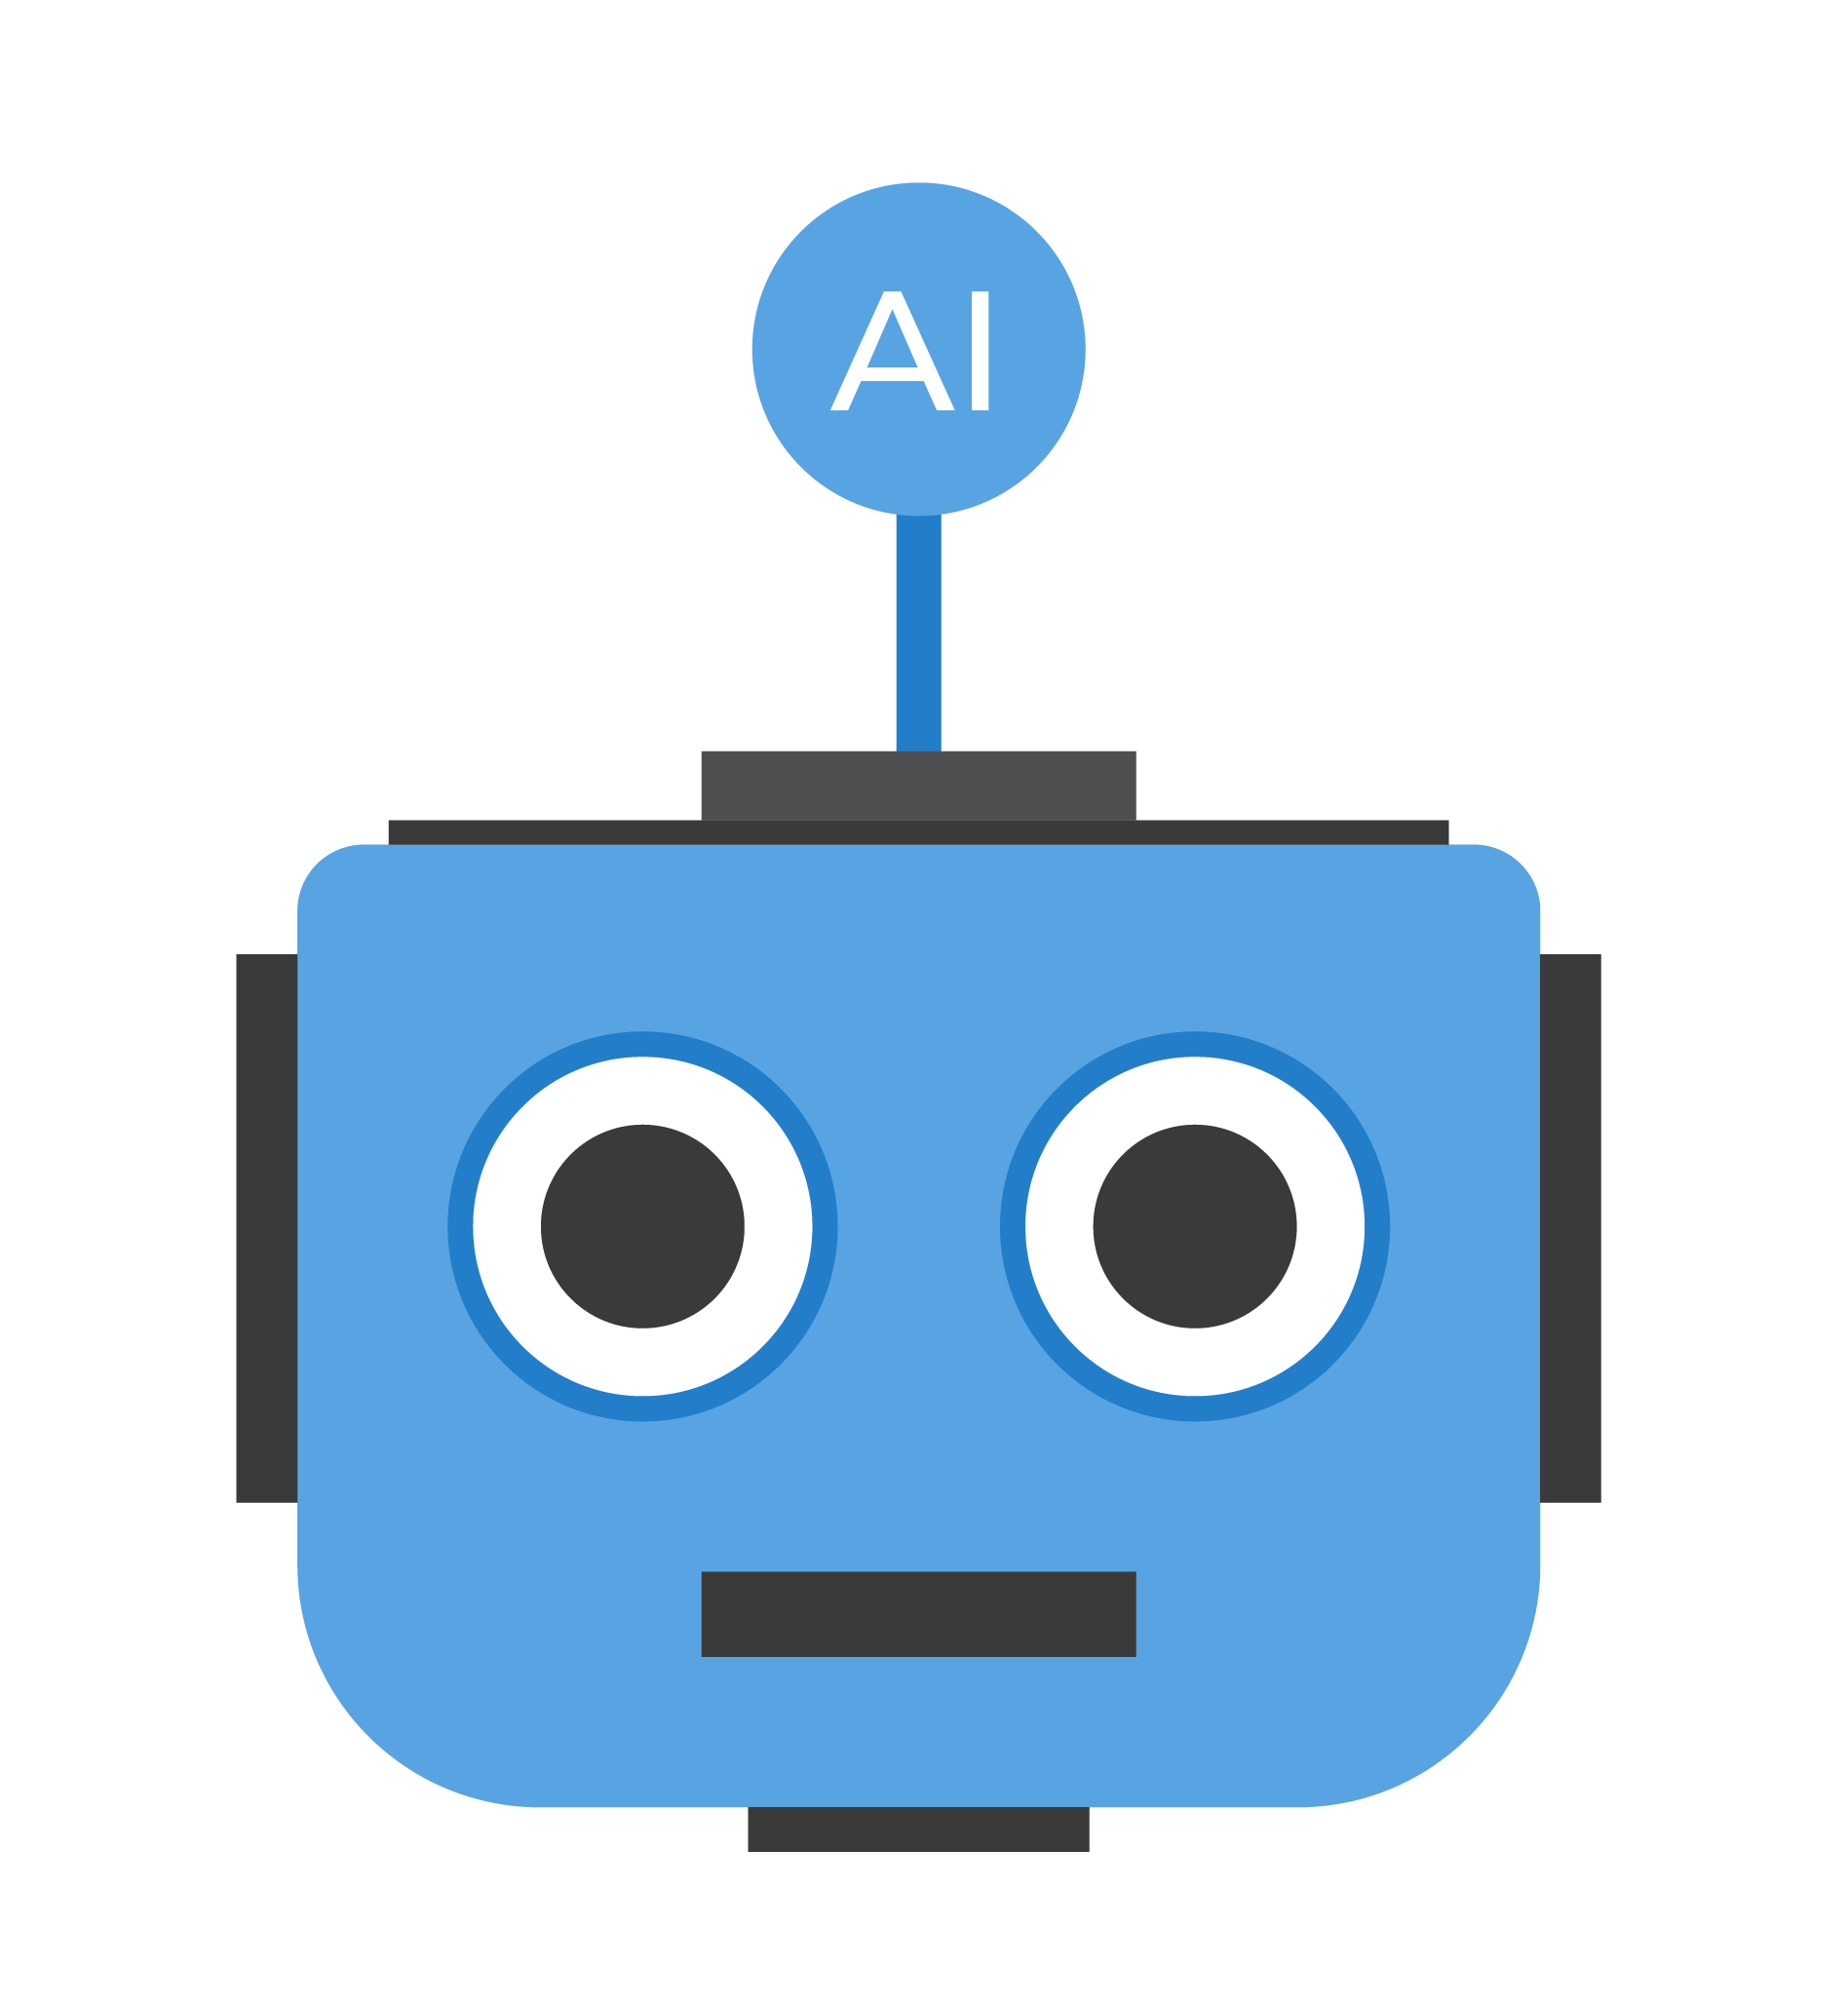</p>
</center>



### 1.1 What is intelligence?

Before we can talk about *artificial* intelligence, we should be honest that we don't have a tidy definition
of plain intelligence either. It's slippery. It looks different in a chess grandmaster, a jazz musician, and
a crow figuring out how to reach food with a stick. The definition I find most useful is this: intelligence
is the ability to achieve goals in the world, and sitting underneath it are two things: 

- the ability to *learn* and the ability to *solve problems*.

Here's what I want you to notice. You are running an enormous amount of intelligence right now without any
awareness of it. The way you hold a spoon, tie your shoelaces, pick your friend's face out of a crowded room,
know which side of the bed is yours — nobody sat you down and programmed those rules into you. You picked them
up from experience. Keep that word, *experience*, in the back of your mind. It's about to become the whole
game.

### 1.2 So what is artificial intelligence?

The one-line version I want you to remember:

> Artificial intelligence is the science and engineering of getting machines to do things that would require
> intelligence if a human did them.

Think of it this way. The industrial revolution built machines that did our physical work for us. AI is the
attempt to build machines that do some of our *thinking* work — the repetitive, tedious, mentally heavy stuff
— and now and then, to crack problems we simply can't crack ourselves.

Now let me put a question to you before we go on, because it's the seed of everything in Section 3. 

*A pocket calculator does arithmetic far faster than any of us. Is a calculator AI?* 

Sit with that for a second before
you answer. The reason it feels wrong to call it intelligent is that it only ever does exactly what someone
told it to do, and it never gets any better no matter how many sums it works through. 

That gap — between following rules a human wrote and actually *learning* from experience — is the line we're going to draw very
sharply in a few minutes.

---
## 2. AI vs ML vs DL

You'll hear these three terms thrown around as if they mean the same thing, especially in the news. They
don't. The cleanest way to hold them in your head is as three circles sitting one inside the other, like
Russian dolls.

The outermost circle is **artificial intelligence** — the whole ambition of making machines act intelligently,
by whatever means. That includes plenty of things that don't learn at all: search algorithms, planning,
old-school rule-based "expert systems."

Inside that sits **machine learning**, which is one particular strategy for getting to AI: instead of writing
the rules ourselves, we let the machine figure them out from data. There's a line I want you to write down —
*data is to machine learning what code is to ordinary software.* In traditional programming, code is the
thing you author. In ML, data is.

And tucked inside machine learning is **deep learning**, the approach behind most of the headlines. These are
models made of many stacked layers of artificial "neurons" that build understanding gradually — early layers
notice edges, later ones notice shapes, later still, whole faces. When your phone recognises your face or
translates a sign through the camera, that's deep learning.

Rather than just tell you they nest, let me draw it so it sticks.

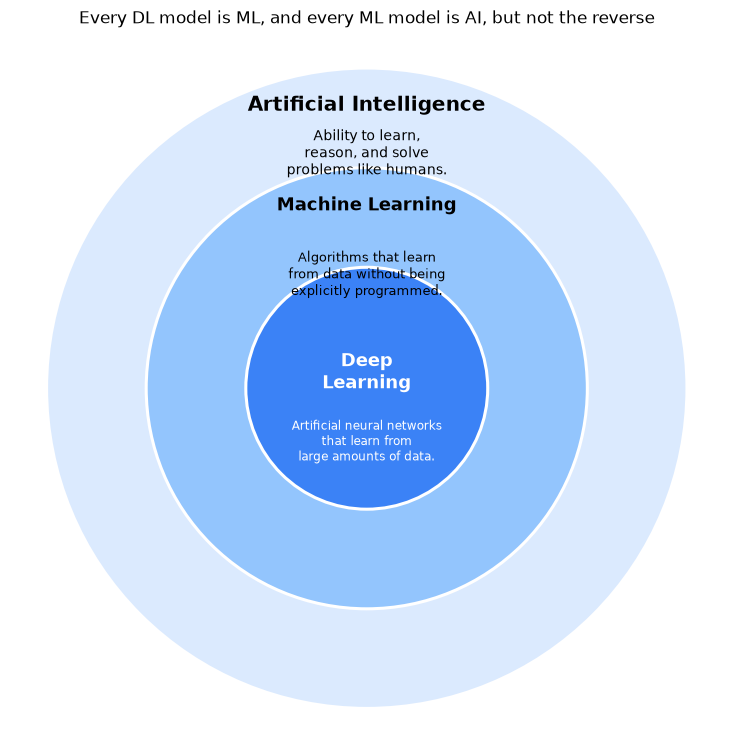

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

# Draw circles
for radius, color in [(90, "#dbeafe"), (62, "#93c5fd"), (34, "#3b82f6")]:
    ax.add_patch(plt.Circle((0, 0), radius, color=color, ec="white", lw=2))

# Titles
ax.text(0, 78, "Artificial Intelligence", ha="center",
        fontsize=13, fontweight="bold")

ax.text(0, 50, "Machine Learning", ha="center",
        fontsize=12, fontweight="bold")

ax.text(0, 0, "Deep\nLearning", ha="center",
        fontsize=12, fontweight="bold", color="white")

# Descriptions
ax.text(
    0, 66,
    "Ability to learn,\nreason, and solve\nproblems like humans.",
    ha="center", va="center", fontsize=9
)

ax.text(
    0, 32,
    "Algorithms that learn\nfrom data without being\nexplicitly programmed.",
    ha="center", va="center", fontsize=8.5
)

ax.text(
    0, -15,
    "Artificial neural networks\nthat learn from\nlarge amounts of data.",
    ha="center", va="center", fontsize=8,
    color="white"
)

ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "Every DL model is ML, and every ML model is AI, but not the reverse",
    fontsize=11
)

plt.tight_layout()
plt.show()

### 2.1 The same product can live in a different ring

The distinction isn't academic. The same-looking feature can sit in a completely different ring depending on
how it works under the hood, and it's worth training your eye to tell them apart.

| Feature you've used | Which ring | Why |
|---|---|---|
| A chess engine grinding through possible moves | AI, but not ML | It follows rules and searches ahead; it isn't learning from data |
| A streaming service nudging you toward your next show | ML | It learned your taste from what you've watched |
| Face unlock on your phone | DL | A deep network learned your face straight from pixels |
| A thermostat running a schedule you typed in | none of them | Fixed rules, no intelligence to speak of |

Here's one to chew on. Early spam filters were just hand-written rules — block anything containing a
particular phrase — and they were terrible, because spammers simply changed the phrase. Modern ones learned
from millions of emails people had marked as spam or not. In terms of our rings, which one did spam filtering
move *out of*, and which did it move *into*? That little migration is basically the story of the last twenty
years of software.

---
## 3. Traditional programming vs. machine learning

If you take one idea away from today, make it this one. Everything else is detail.

For your whole life as a programmer up to now, the deal has been: *you* write the rules. You sit down, you
think hard about the problem, and you spell out step by step what the computer should do. The computer takes
those rules, applies them to some data, and out come answers. It does exactly what you said — no more, no
less. That's traditional programming.

Machine learning flips that deal on its head. You don't write the rules. Instead you hand the machine a pile
of examples — the data *and* the answers that go with them — and you ask it to figure out the rules for
itself. The rules become the *output* of the process, not the input.

```
Traditional programming:   Rules + Data              ->  Answers
Machine learning:          Data  + Answers (labels)  ->  Rules   (we call these rules the "model")
```

Look at those two lines and notice that the arrows have been reversed. That reversal is the entire revolution.
Because the machine worked the rules out from examples rather than being handed them, it can often handle
situations you never explicitly thought about — and, as we'll see later, sometimes situations you'd rather it
didn't.

The way I like to picture it: traditional programming is cooking from a recipe someone wrote down for you, one
instruction at a time. Machine learning is the cook who has tasted ten thousand dishes over the years and can
now walk into a kitchen and improvise something that works. Nobody ever wrote that cook a recipe. They
absorbed it from experience. That's the difference between being told the rules and learning them.

<center>
<p>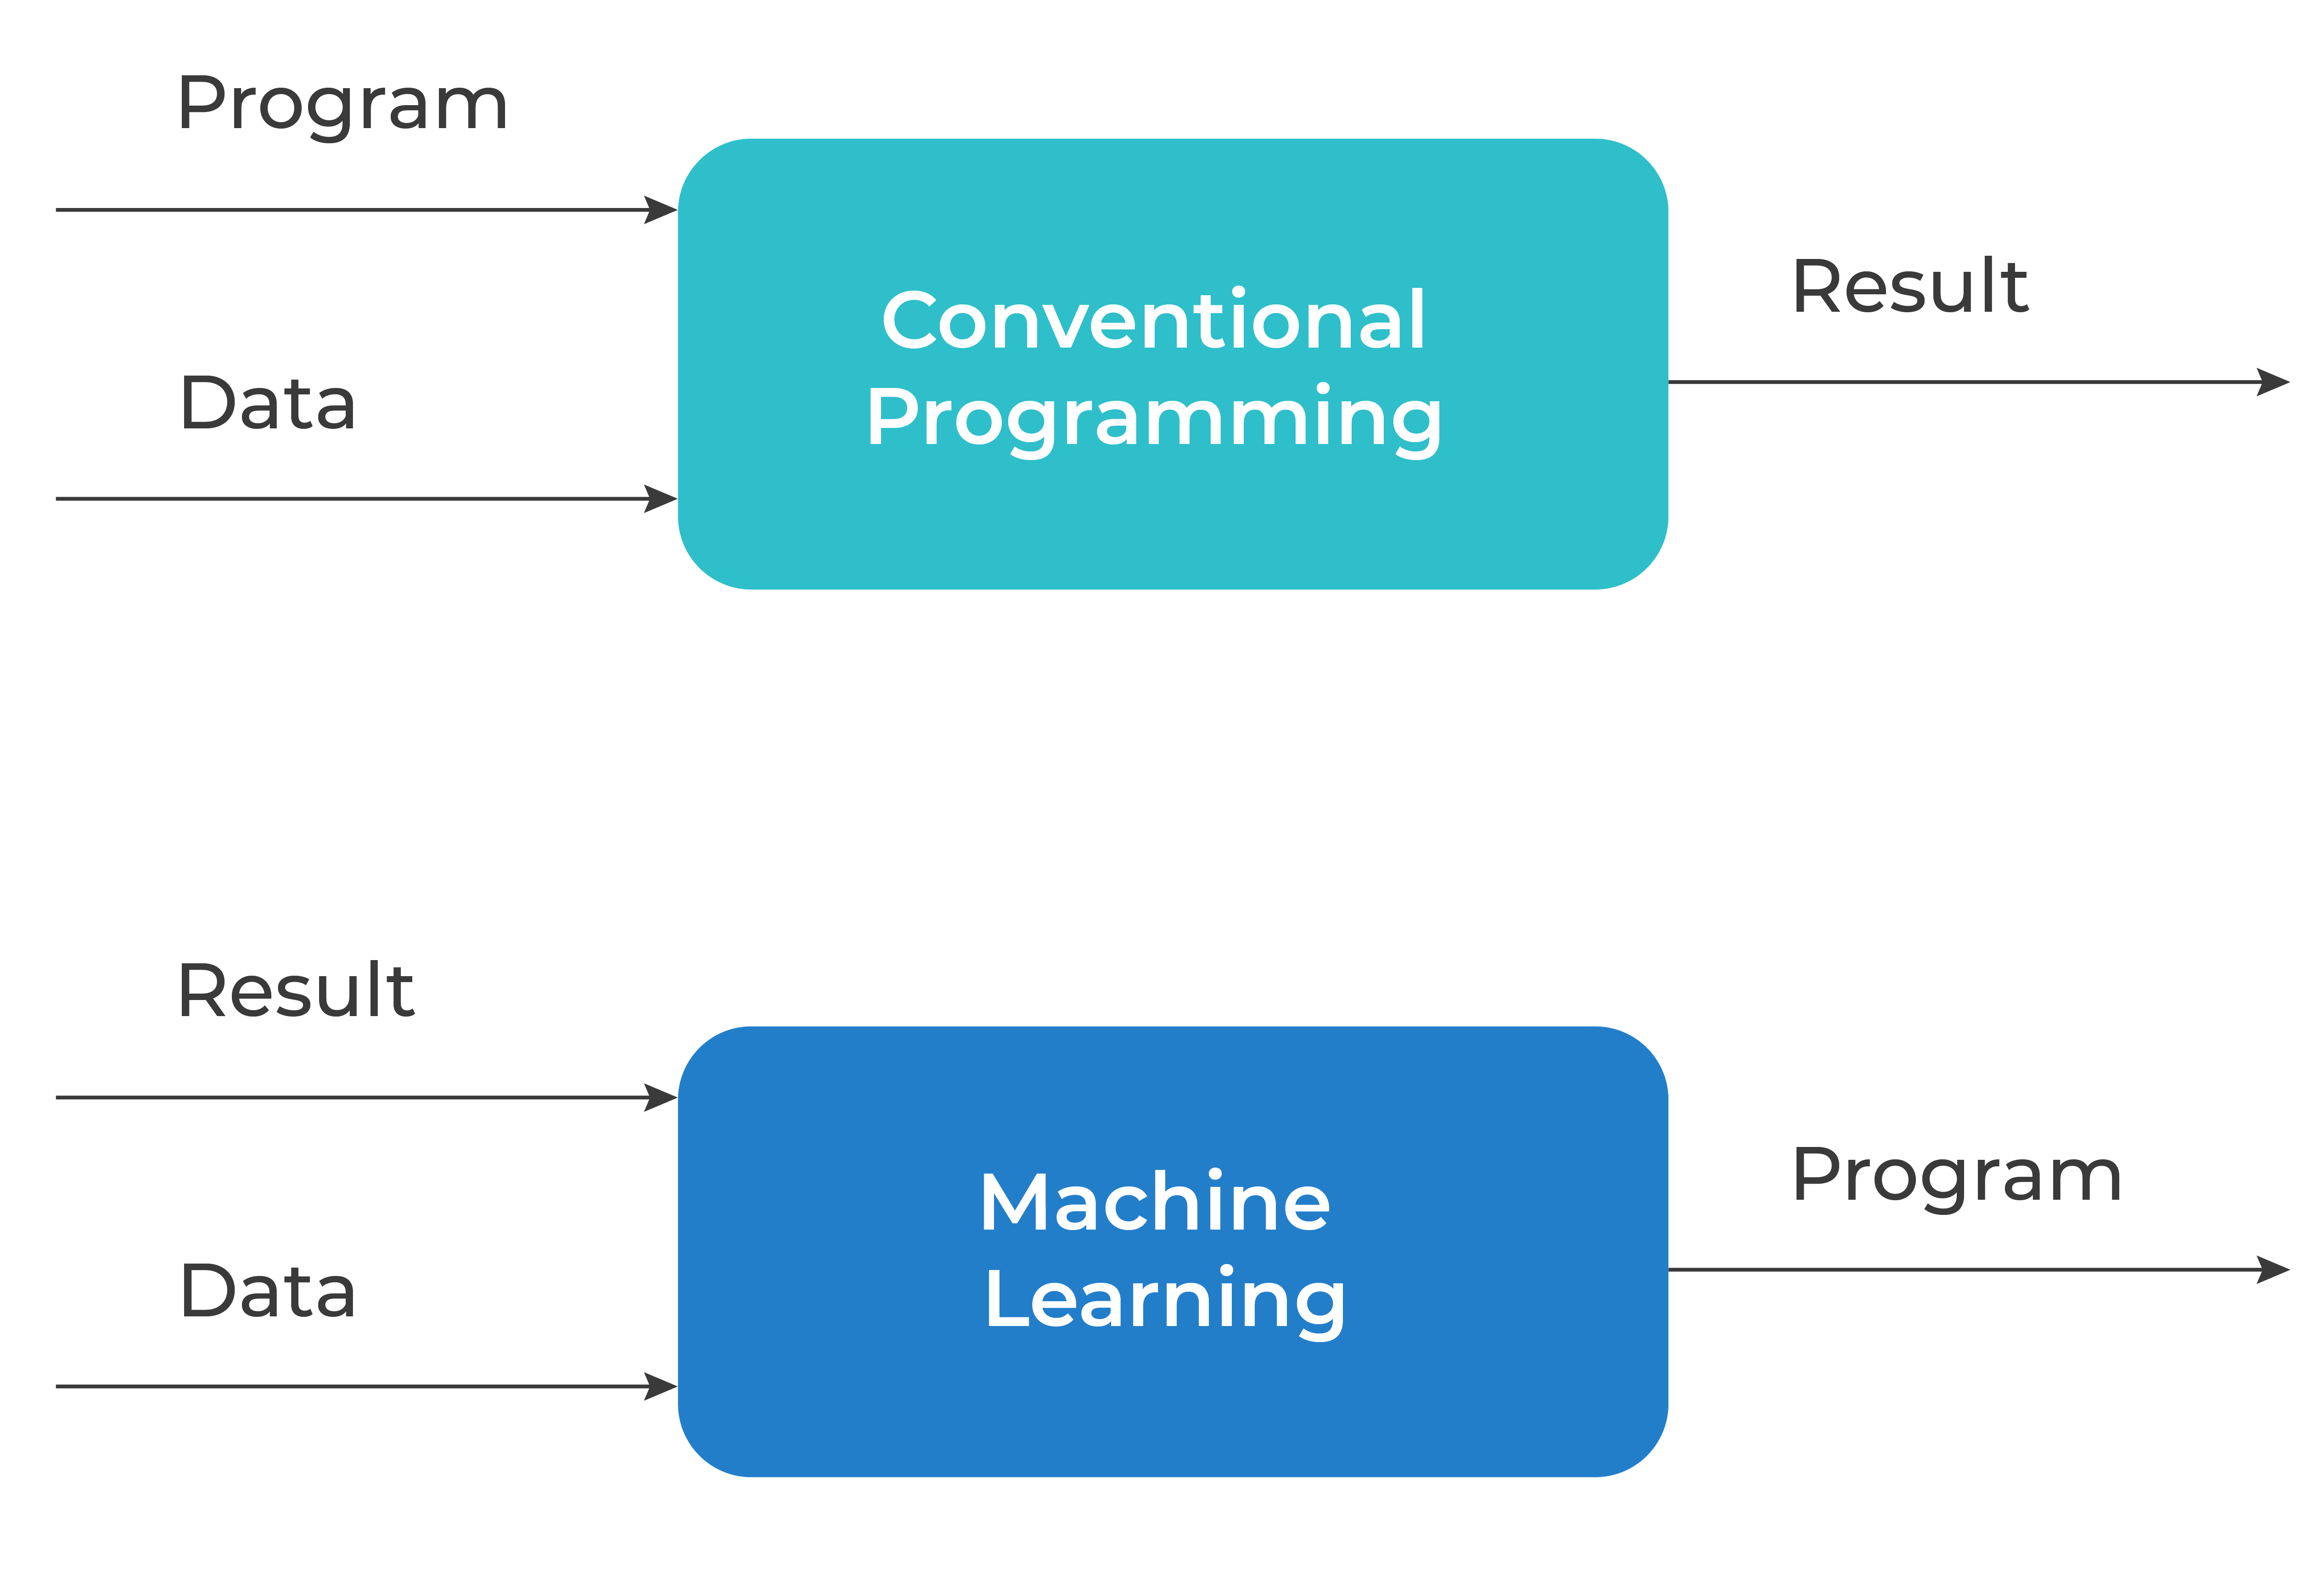</p>

Fig: Traditional(Conventional) Programming Vs. Machine Learning

</center>

### 3.1 Let's watch a machine discover a rule

Talk is cheap, so let me show you this actually happening. You already know how to convert Celsius to
Fahrenheit: $F = 1.8 \times C + 32$. We're going to pretend we've never seen that formula. All we'll give the
machine is a handful of matching `(Celsius, Fahrenheit)` pairs — just examples — and we'll ask it to find the
rule on its own. Watch what comes back.

In [3]:
# We (secretly) know the true rule, but the model does not see it.
celsius    = np.array([-40, -10, 0, 8, 15, 22, 38, 100]).reshape(-1, 1)  # inputs  (data)
fahrenheit = np.array([-40,  14, 32, 46.4, 59, 71.6, 100.4, 212])        # outputs (labels)

# The model: a straight line  F = w * C + b.  It must learn w and b from the examples.
model = LinearRegression()
model.fit(celsius, fahrenheit)   # "learning": finding the rule from data

learned_w = model.coef_[0]
learned_b = model.intercept_
print(f"Rule the model learned : F = {learned_w:.3f} * C + {learned_b:.3f}")
print(f"The actual hidden rule : F = 1.800 * C + 32.000")
print()
print("Predict a value it never saw, 37 C (human body temperature):")
print(f"   Model prediction: {model.predict([[37]])[0]:.1f} F   (true answer: {1.8*37 + 32:.1f} F)")

Rule the model learned : F = 1.800 * C + 32.000
The actual hidden rule : F = 1.800 * C + 32.000

Predict a value it never saw, 37 C (human body temperature):
   Model prediction: 98.6 F   (true answer: 98.6 F)


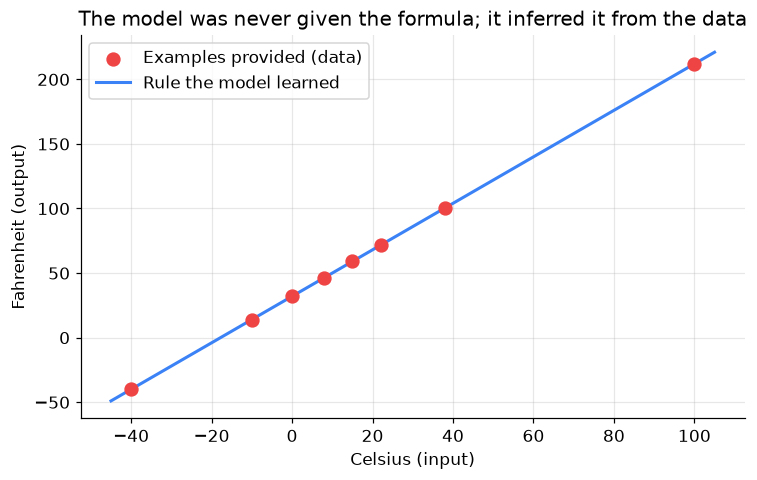

In [4]:
# The dots are the examples we provided; the line is the rule the model inferred.
C_line = np.linspace(-45, 105, 100).reshape(-1, 1)

plt.figure()
plt.scatter(celsius, fahrenheit, s=70, color="#ef4444", zorder=3, label="Examples provided (data)")
plt.plot(C_line, model.predict(C_line), color="#3b82f6", lw=2, label="Rule the model learned")
plt.xlabel("Celsius (input)")
plt.ylabel("Fahrenheit (output)")
plt.title("The model was never given the formula; it inferred it from the data")
plt.legend()
plt.tight_layout()
plt.show()

Sit with that for a second, because it's genuinely a little bit magic. We never told the machine the formula.
We handed it eight dots and it came back with $F = 1.8C + 32$, and then correctly converted a temperature it
had never seen. That is machine learning in miniature: the rule was *learned, not written.*

Now go and break it, because breaking things is how you'll really understand them. Two experiments in that
cell above. First, delete most of the data and leave only two points — does it still find the rule? Second,
and this is the important one, add a nonsense point like `(0, 500)` and re-run. Watch the line get yanked
toward the bad data. That's not a bug; that's the whole story of this field in one image. A model is only ever
as good as the examples you feed it, and we'll come back to exactly this when we talk about the limits of ML
in Section 7.

### 3.2 Now the textbook definition will actually make sense

Most courses hit you with this definition on day one, before you have any feel for it, and it just bounces
off. We've done it the other way round — you've now *seen* learning happen, so Tom Mitchell's classic 1997
definition should land properly:

> A computer program is said to learn from experience $E$ with respect to some class of tasks $T$ and
> performance measure $P$, if its performance at tasks in $T$, as measured by $P$, improves with experience $E$.

Don't be put off by the three letters. Let me just point them at what we literally just did:

| Symbol | What it means | In our temperature demo |
|:---:|---|---|
| $E$ — experience | the data, the past examples | the eight `(C, F)` pairs |
| $T$ — task | the thing we want done | predict Fahrenheit from Celsius |
| $P$ — performance | how we keep score | how far off the predictions are |

The phrase that carries all the weight is "improves with experience $E$." Feed it more good examples, it gets
better. And now go back to the calculator we argued about in Section 1: it never improves with experience, no
matter how many sums it does. By Mitchell's definition it isn't learning at all — which is exactly why it
never felt like intelligence. Question settled.

---
## 4. The anatomy of every ML system

Here's a claim I'll stand behind for the rest of the course: strip away the jargon and *every* machine
learning project you will ever meet — a spam filter, a self-driving car, a chatbot — is built from the same
four parts. Once you can spot these four, no ML paper or product will ever feel like a total black box again.

The first is **data**: the examples the system learns from. Nothing happens without it.

The second is the **model**: the *form* of the rule we're going to learn. Is it a straight line? A tree of
yes/no questions? A neural network? Choosing a model is really choosing a shape for the answer, and with it a
whole space of possible rules of that shape. (You'll hear that space called the *hypothesis space* — it's just
"all the rules this kind of model could possibly represent.")

The third is **learning**, and this is where the actual work happens. Learning is the search through that
space for the *best* rule, and it comes in two halves. One half is the **objective function**, which is just a
number that says how wrong a candidate rule is — lower is better. The other half is **optimization**, the
procedure that keeps nudging the model to make that number smaller. You'll meet mean squared error and
gradient descent as the classic examples, and we'll actually look at both in a moment.

The fourth is **application**: once it's trained, we point the model at new data and put it to work —
predicting, recommending, flagging, whatever the job was.

If that feels abstract, think about learning to shoot a basketball. Every practice shot you take is your
*data*. Your shooting form — the adjustable thing — is your *model*. How far the ball misses the hoop is your
*objective*, and you badly want to make it smaller. Tweaking your elbow and knees after each miss is
*optimization*. And sinking the shot in an actual game is the *application*. Same four parts, no maths
required.

### 4.1 What does "best" actually mean? Let's see the objective

Back in Section 3, scikit-learn quietly handed us "the best line" and we just trusted it. But that should
bug you a little — best according to *what*? This is where the objective function earns its keep. For fitting
a line, the traditional answer is mean squared error, or MSE: take the vertical gap between each point and the
line, square it, and average over all the points.

$$\text{MSE}(w, b) = \frac{1}{n}\sum_{i=1}^{n} \big(y_i - (w x_i + b)\big)^2$$

Squaring does two jobs: it makes every gap positive so they can't cancel out, and it punishes big misses much
harder than small ones. "Learning the best line" now has a precise meaning — find the slope $w$ and intercept
$b$ that make this number as small as it can go. Let me make that concrete. In the cell below I'll hold the
intercept fixed and just try a whole range of slopes, recording how wrong each one is, so we can literally see
the "best" emerge.

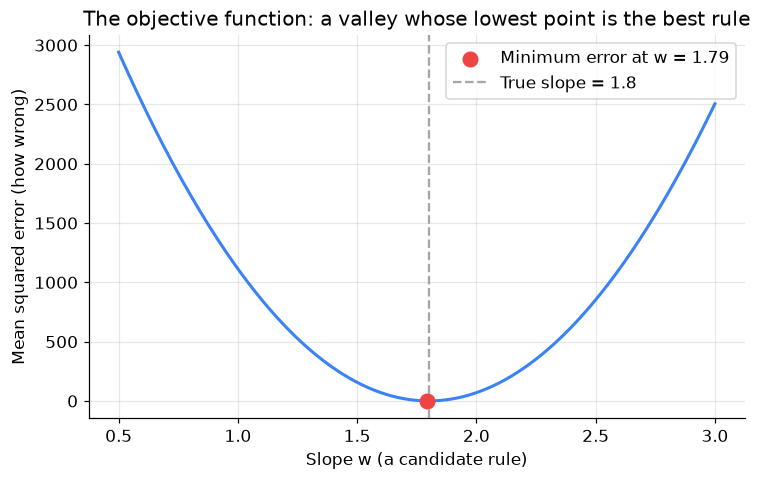

In [5]:
# Reuse the temperature data. Sweep the slope w and record the MSE for each value.
def mse(w, b, X, y):
    preds = w * X.ravel() + b
    return np.mean((y - preds) ** 2)

w_values = np.linspace(0.5, 3.0, 200)            # candidate slopes to try
errors   = [mse(w, learned_b, celsius, fahrenheit) for w in w_values]
best_w   = w_values[int(np.argmin(errors))]

plt.figure()
plt.plot(w_values, errors, color="#3b82f6", lw=2)
plt.scatter([best_w], [min(errors)], color="#ef4444", s=90, zorder=3,
            label=f"Minimum error at w = {best_w:.2f}")
plt.axvline(1.8, ls="--", color="gray", alpha=0.7, label="True slope = 1.8")
plt.xlabel("Slope w (a candidate rule)")
plt.ylabel("Mean squared error (how wrong)")
plt.title("The objective function: a valley whose lowest point is the best rule")
plt.legend()
plt.tight_layout()
plt.show()

There it is — a U-shaped valley. And now optimization stops being a scary word. Picture setting a ball down
somewhere on that curve and letting go: it rolls downhill until it settles at the bottom. That's essentially
what gradient descent does — from wherever it starts, it keeps stepping downhill until it reaches the lowest
point, which is the best rule. Notice where the bottom lands: right at a slope of 1.8, exactly the answer
scikit-learn gave us earlier. Two different methods, same truth.

One thing to file away for later, though. Our valley has a single, obvious bottom. What if a curve had two
dips — a deep one and a shallow one? A ball rolling downhill might roll into the shallow dip and get stuck
there, never finding the real bottom. That trap has a name, *local minima*, and it's going to haunt us when we
reach deep learning. For now, just enjoy that our simple problem doesn't have that headache.

---
## 5. The three types of machine learning

When people carve up machine learning into types, the thing they're really asking is: *how much hand-holding
does the machine get?* That gives us three families, and I find it helps to give each one a little personality:

Supervised learning is the eager student — "please, teach me, show me the answers." It learns from examples
that come with the correct answer attached.

Unsupervised learning is the independent one — "leave me alone, I'll find the patterns myself." It gets data
with no answers and has to make sense of it unaided.

Reinforcement learning is the rebel — "my life, my rules." Nobody gives it answers at all; it just tries
things and learns from whether they went well or badly.

Let's meet all three properly, each with a picture and some code you can run.

<center>
<p>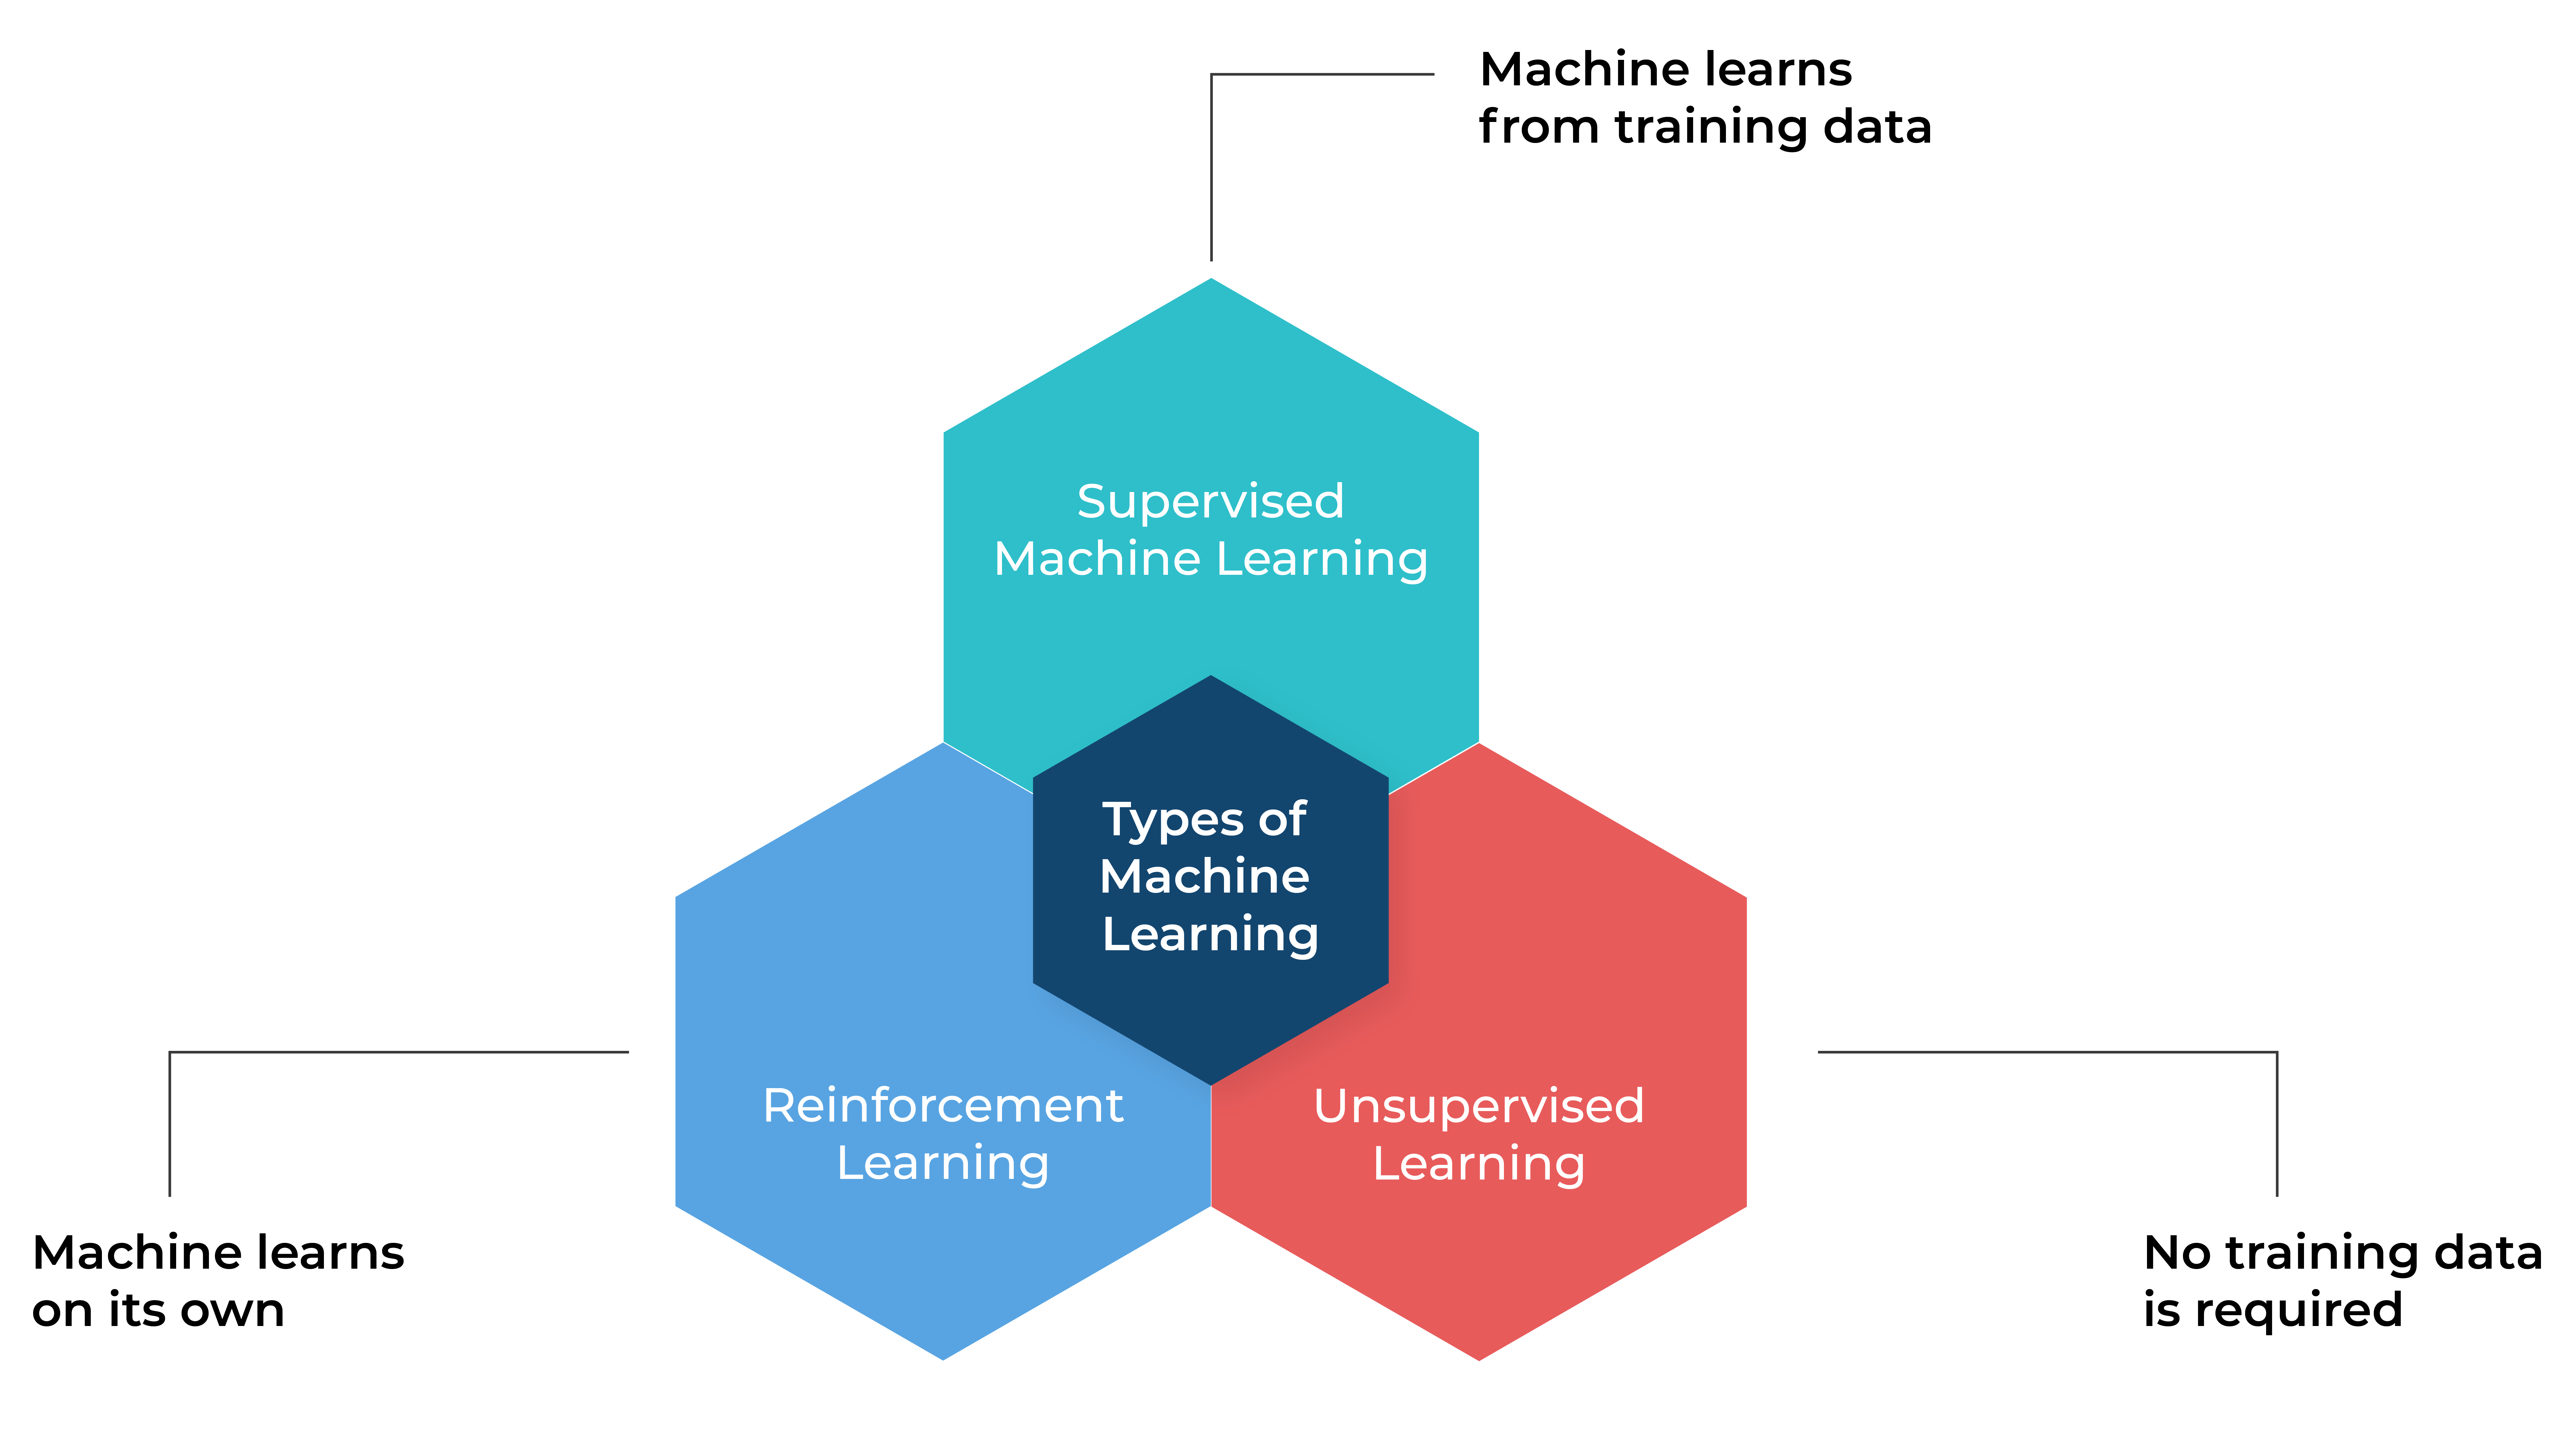</p>

Fig: Types of Machine Learning
</center>

### 5.1 Supervised learning

This is the one you'll spend the most time with, so let's get it right. In supervised learning you give the
model both the inputs and the correct answers — we call those answers *labels* — and its job is to learn the
connection between them. Once it's learned that connection, you throw a brand new input at it that it's never
seen, and it predicts the label.

If you want the formal version: you hand it a training set $\{(x_1, y_1), \dots, (x_n, y_n)\}$ and it looks for
a function $f$ so that $f(x) \approx y$ on future data too. That $x$ is the input (the *features*), and $y$ is
the answer.

The cleanest picture I have for this is flashcards. A tutor holds up a card with a picture on the front and
the answer on the back. Front, back, front, back — after enough cards, you can name a picture you've never
seen before. The answers on the back are the "supervision," and that's literally where the name comes from.

Supervised learning comes in two flavours depending on what kind of answer you're predicting. If the answer is
a *category* — apple or not-apple, spam or not-spam — that's **classification**. If the answer is a *number* —
a house price, tomorrow's temperature — that's **regression**, which is exactly what our Celsius demo was.

Let's do a classification example. Each dot below has a position (its features) and a colour (its label), and
the model's job is to learn a *decision boundary* — a line that separates one colour from the other.

<center>
<p>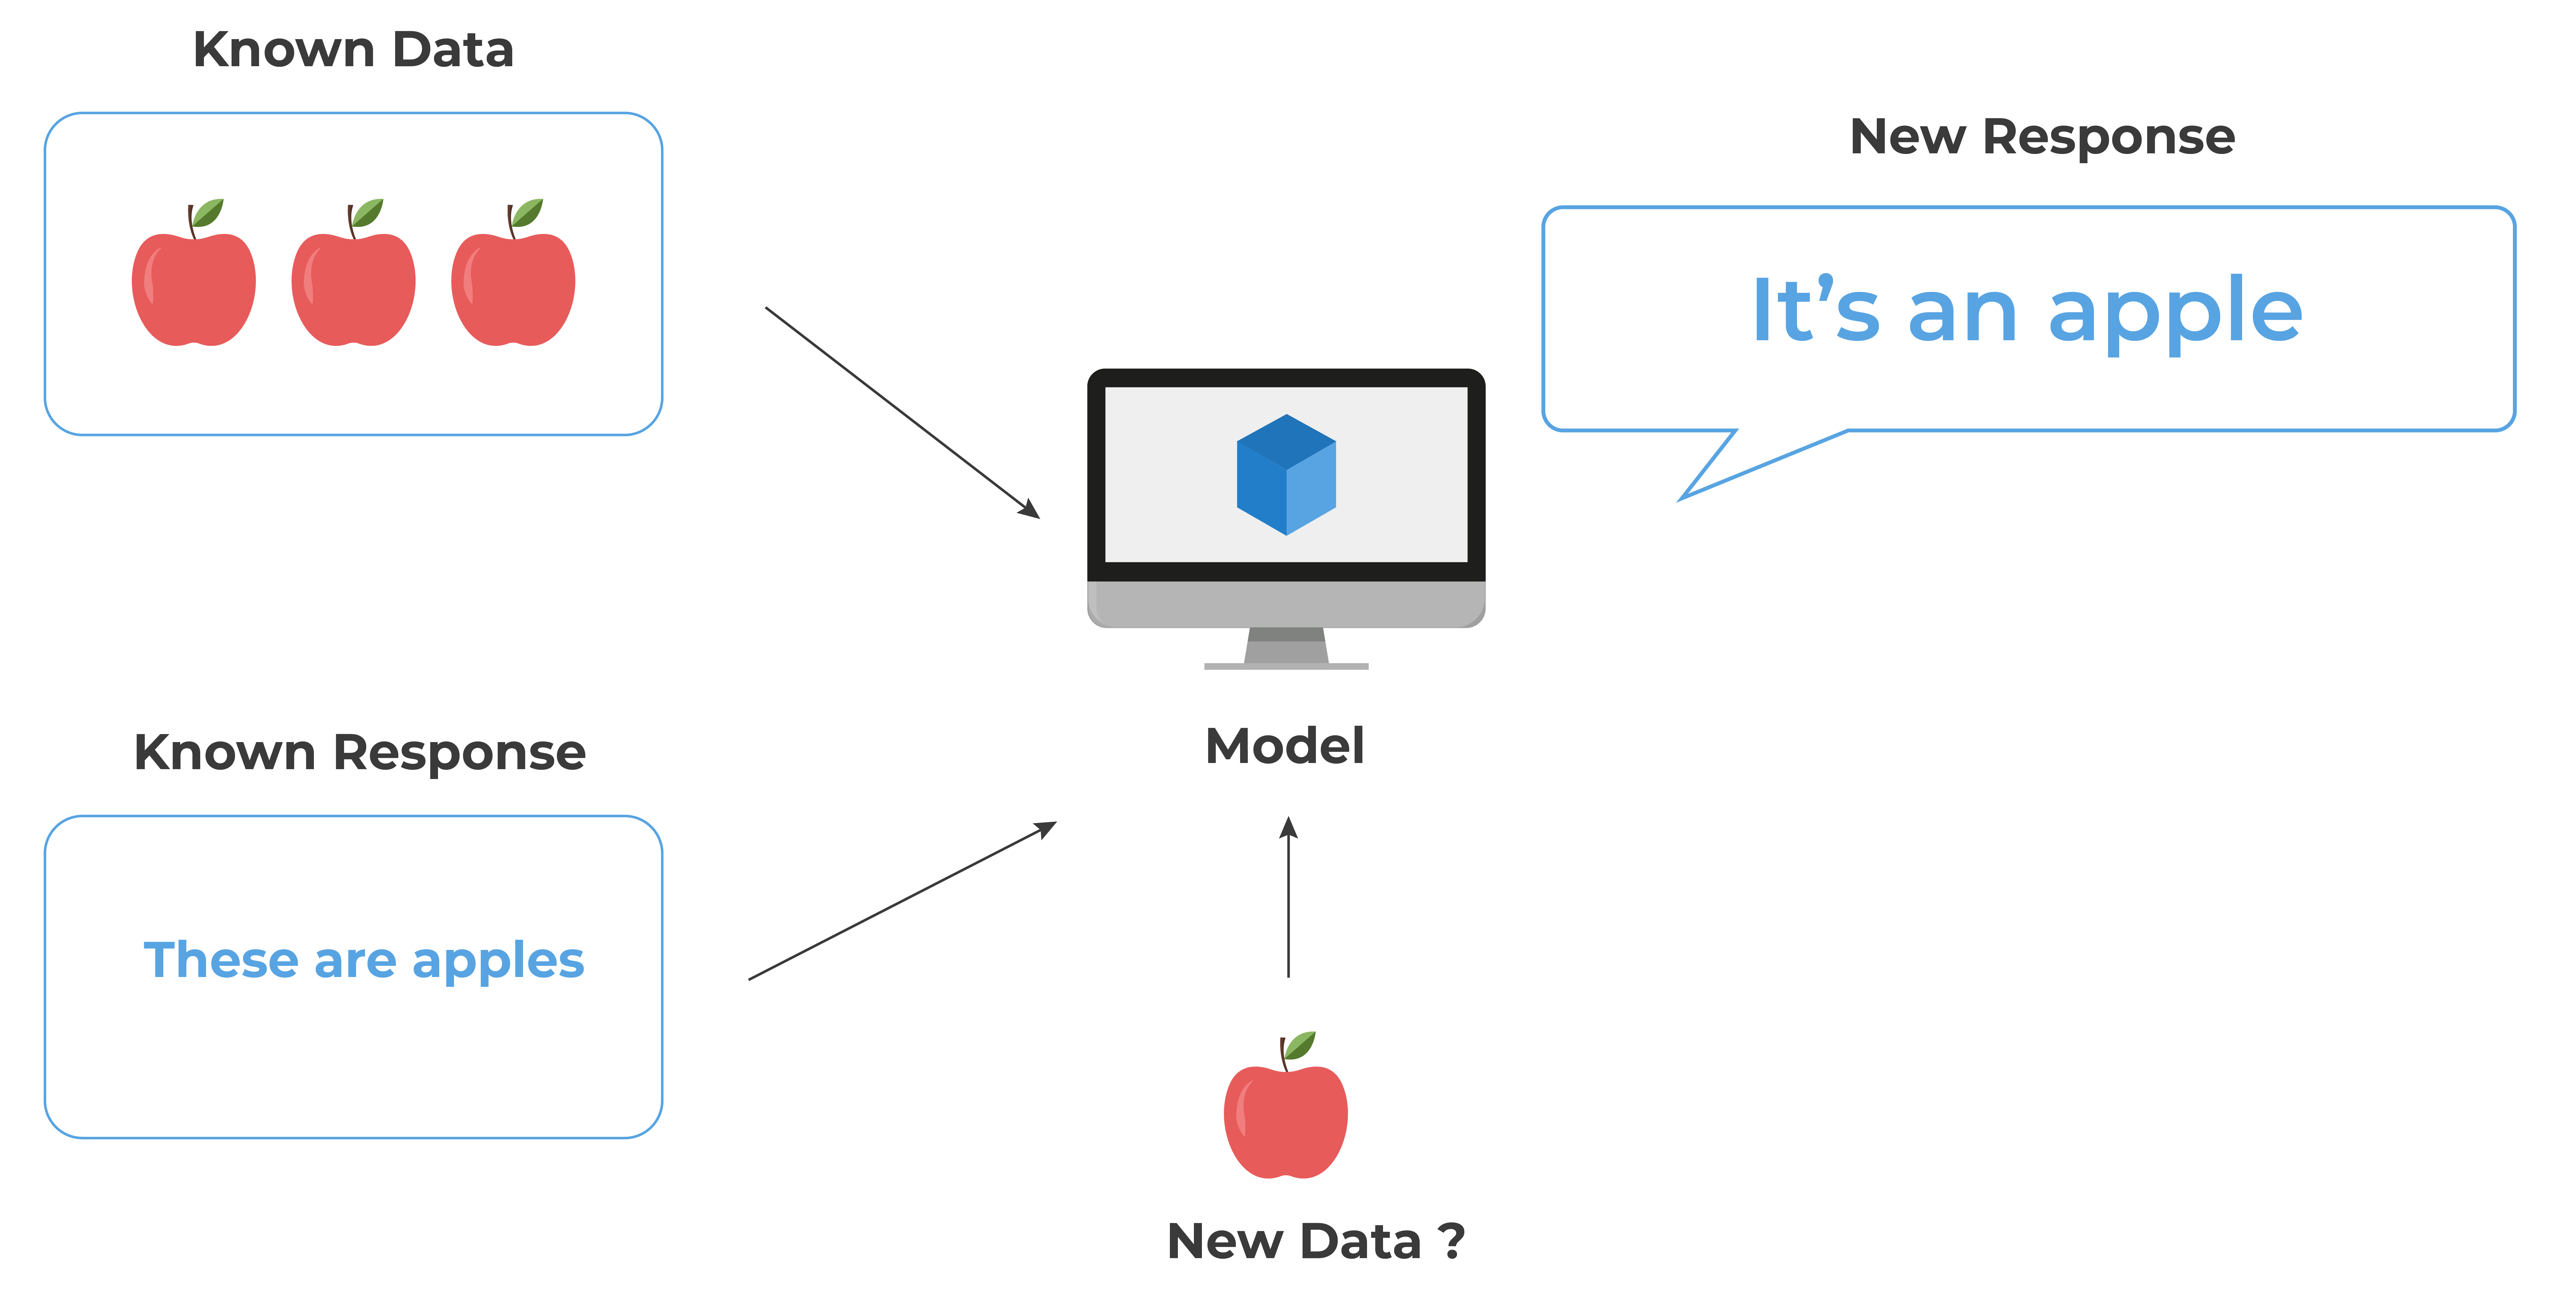</p>

Fig: Supervised Learning

</center>

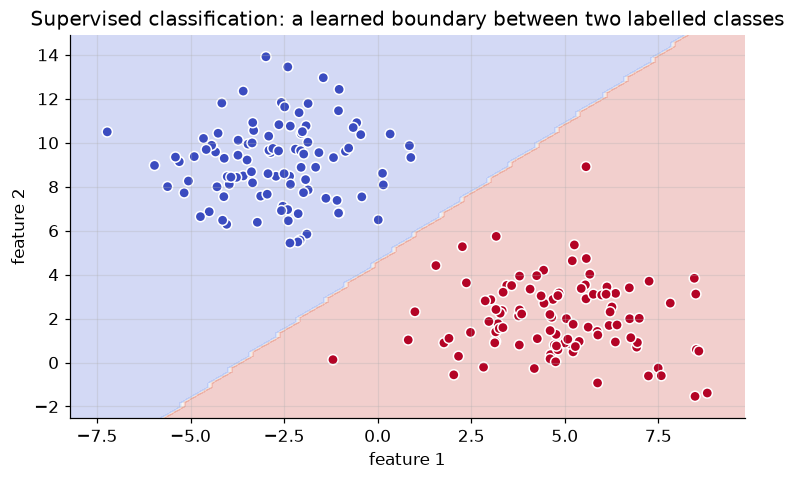

A new point at [0, -6] is predicted to be class: 1


In [6]:
from sklearn.inspection import DecisionBoundaryDisplay

# 200 labelled points in two clusters: a binary classification task.
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.8, random_state=RANDOM_STATE)

clf = LogisticRegression().fit(X, y)     # learn the boundary from labelled data

fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
    clf, X, ax=ax, alpha=0.25, cmap="coolwarm", response_method="predict")
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=45)
ax.set_title("Supervised classification: a learned boundary between two labelled classes")
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

# Predict the class of a new point the model never saw.
new_point = [[0, -6]]
print(f"A new point at {new_point[0]} is predicted to be class: {clf.predict(new_point)[0]}")

The model drew a boundary, and any new point falls on one side or the other. That's it — that's a classifier.

And this isn't a toy idea. The spam filter that cleans your inbox, the system that reads the diagnosis off a
medical scan, the fraud alert when your card gets used somewhere odd, the software that reads the postcode off
an envelope — all of it is supervised classification, just with more features and fancier boundaries. Swap the
category for a number and you get regression: predicting prices, demand, temperatures. Most of the ML running
the world right now is supervised learning, which is why we start here.

### 5.2 Unsupervised learning

Now take the answer key away. In unsupervised learning the model only ever sees the inputs — no labels, no
"back of the flashcard" — and it has to find structure entirely on its own. The most common thing we ask it to
do is *clustering*: look at a pile of things and sort them into groups of similar items, without being told
what the groups are.

Formally, for clustering: given points $x_1, \dots, x_n$, produce an assignment that says which group each
point belongs to. But honestly the everyday version explains it better. Imagine tipping out a big box of mixed
LEGO on the floor. Nobody tells you the categories, yet within a minute you're building piles — long flat
pieces here, little cubes there, wheels in their own heap. You grouped by similarity, with no instructions.
That's clustering, and that's the whole idea.

Watch the contrast in the next cell. On the left is exactly what the algorithm receives: a grey blob of points
with no labels at all. On the right is what it manages to figure out.

<center>



<p>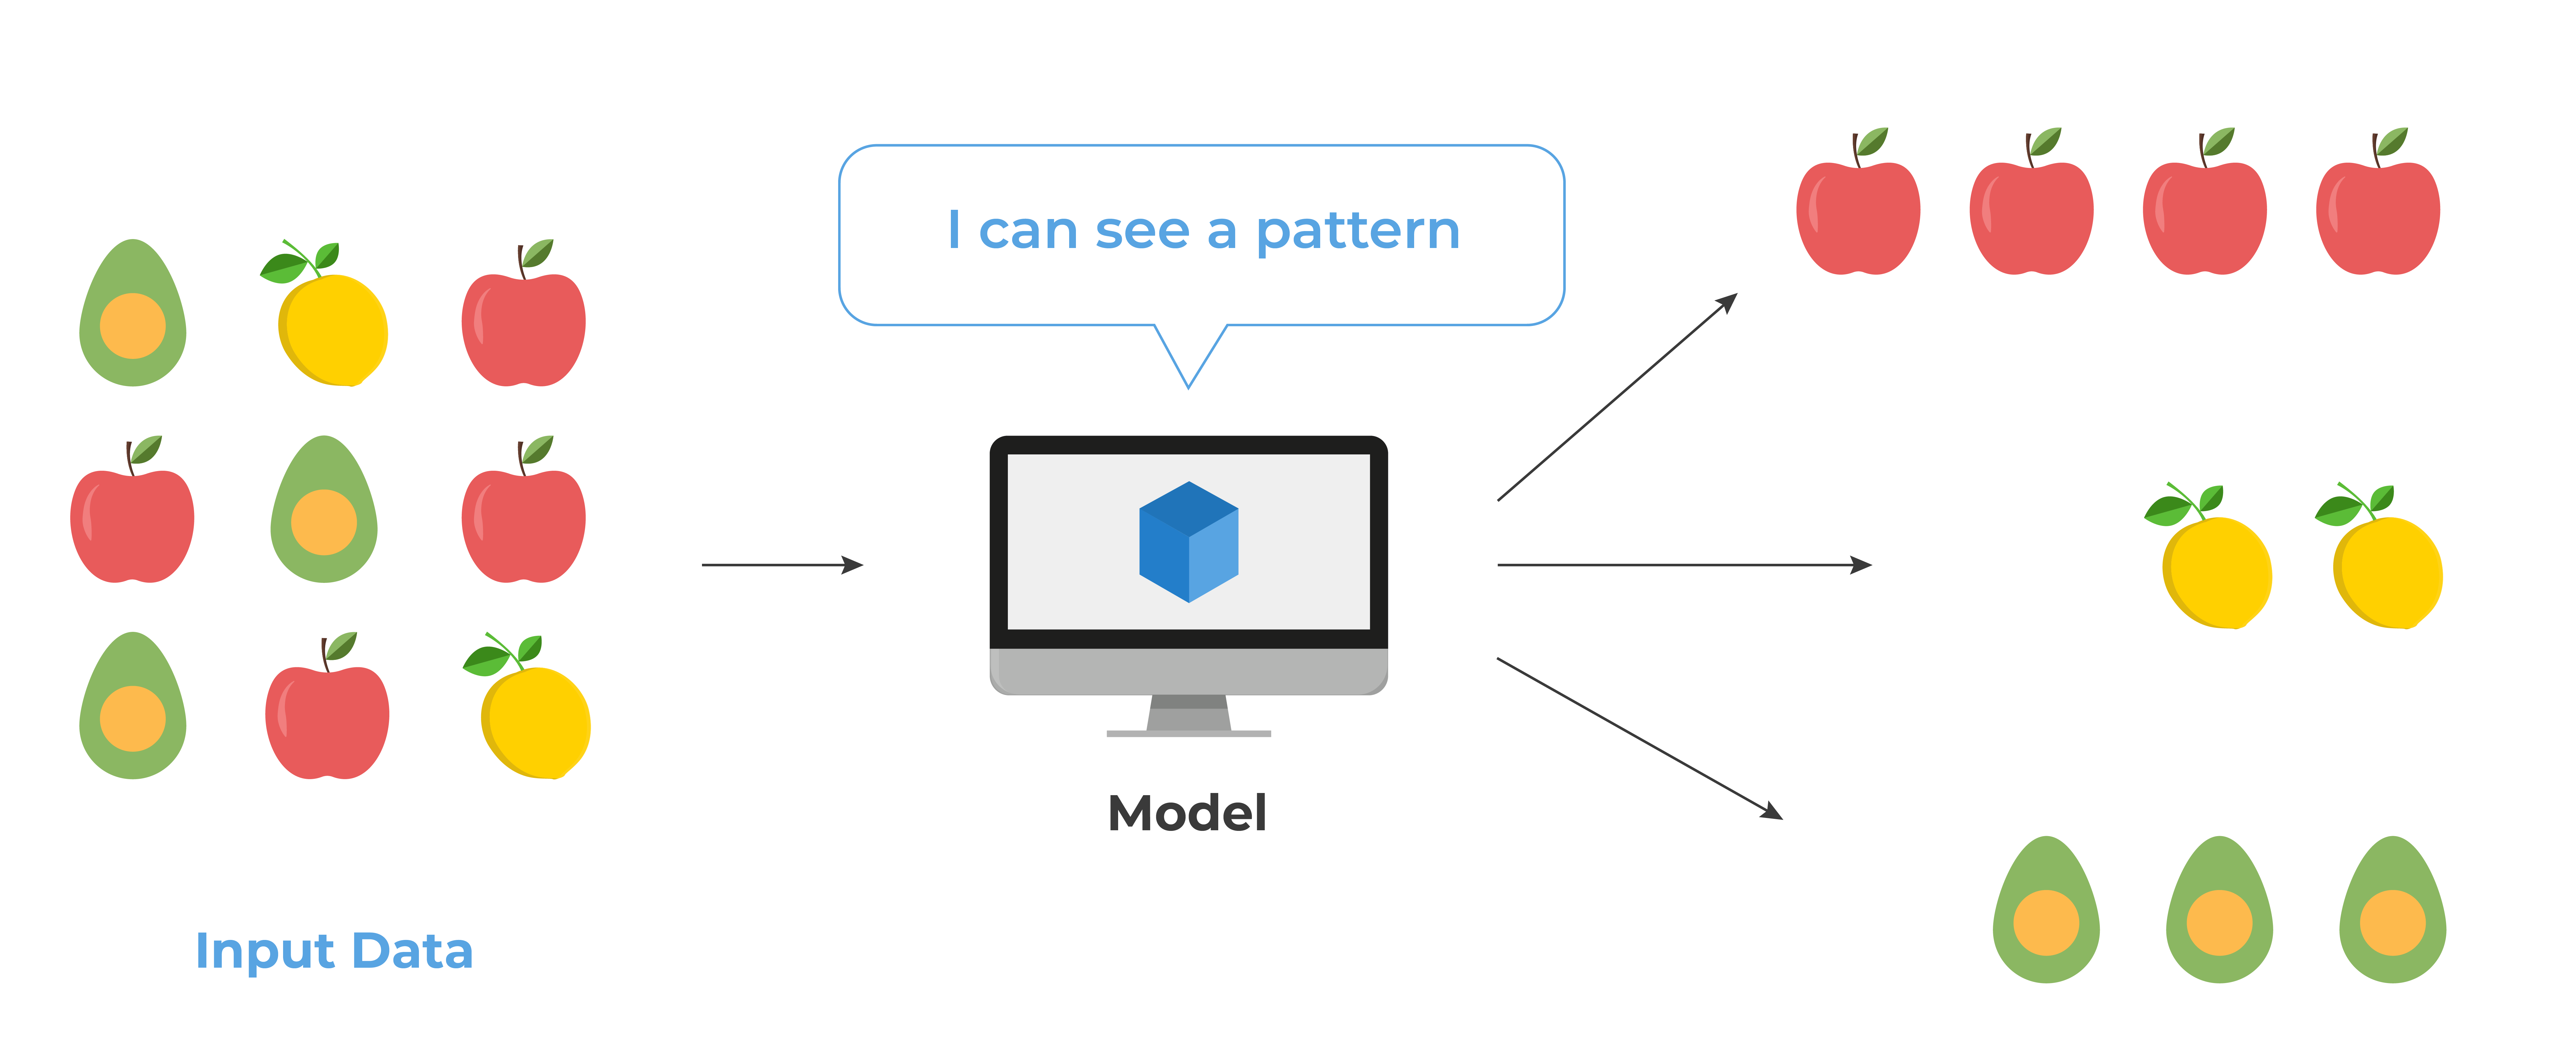</p>

</center>

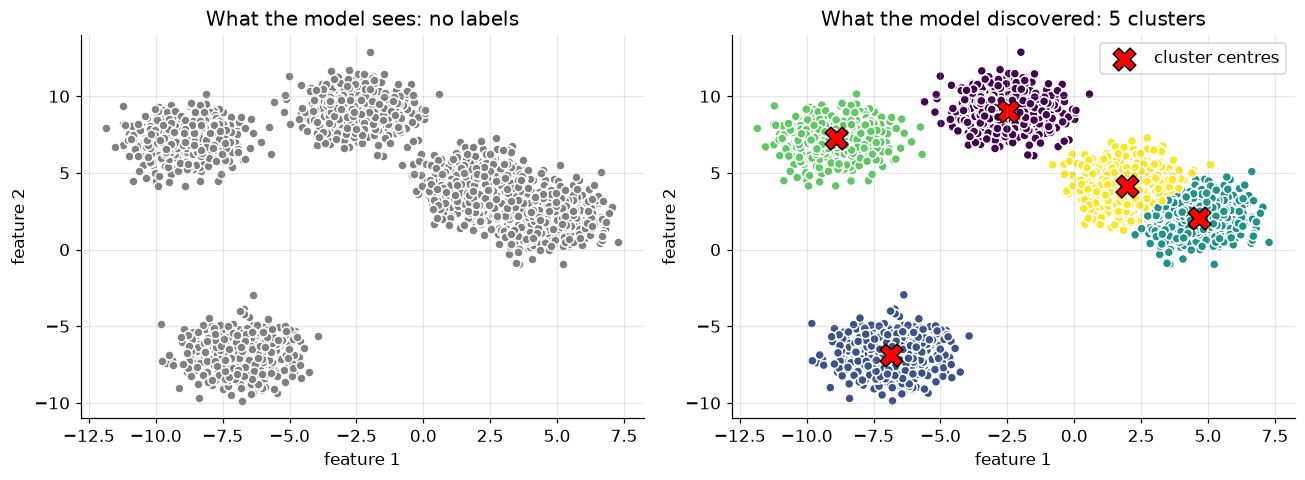

In [7]:
from sklearn.cluster import KMeans

# Three real groups exist, but the labels are not given to the algorithm.
X, y_true = make_blobs(n_samples=3000, centers=5, cluster_std=1.0, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: what the algorithm receives, an unlabelled cloud of points.
axes[0].scatter(X[:, 0], X[:, 1], c="gray", edgecolor="white", s=35)
axes[0].set_title("What the model sees: no labels")

# Right: KMeans discovers 3 clusters and marks their centres, using only the point positions.
km = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE).fit(X)
axes[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="viridis", edgecolor="white", s=35)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c="red", marker="X", s=220, edgecolor="black", label="cluster centres")
axes[1].set_title("What the model discovered: 5 clusters")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

It never saw a single label, and yet it found the three groups — purely from noticing which points huddle near
each other. Nobody supervised it.

This is quietly everywhere: shops segmenting customers into "types" they didn't know they had, news sites
grouping articles by topic, security systems spotting the odd transaction that belongs to no normal cluster,
even image compression. But I want to flag one honest difficulty. Because there are no labels, there's no
answer sheet to check against, which means judging whether an unsupervised result is any *good* is genuinely
harder than in supervised learning. You'll feel that tension in Module 9.

And notice the assumption we smuggled in: we *told* KMeans to find three clusters. What if we'd asked for two,
or five? Would it have obliged? (It would — that's the problem.) Deciding how many groups there really are is
one of the trickier questions in this whole area, and it's not always obvious even to a human. We'll take it
seriously in the clustering module.

### 5.3 Reinforcement learning

The last family is the strangest and, to me, the most fascinating. There's no dataset sitting on a disk at
all. Instead we have an *agent* dropped into an *environment*. It takes *actions*, and the environment answers
back with a *reward* or a penalty. Nobody ever tells the agent the right move. It just tries things and,
little by little, learns a *strategy* — the technical word is a *policy* — that racks up as much reward as
possible over the long run.

The loop it lives in looks like this, over and over:

```
   +-------------+   action a_t     +----------------+
   |    AGENT    | ---------------> |  ENVIRONMENT   |
   | (learns pi) | <--------------- |                |
   +-------------+  state s_{t+1},  +----------------+
                    reward r_{t+1}
```

If you've ever trained a dog, you already understand this. You never handed the puppy a spreadsheet of correct
behaviours. It tried things; sitting earned a treat, chewing the sofa didn't. Over time it worked out a policy
— "when they say sit, sitting pays off." That's reinforcement learning with fur.

We'll do the simplest possible version, a classic called the *multi-armed bandit*. Picture three slot
machines, each paying out at some hidden rate you don't know. Every pull, you have to choose one. And here's
the delicious tension at the heart of the whole field: do you keep pulling the machine that's looked best so
far (that's *exploiting*), or do you gamble a pull on a different machine to learn more about it (that's
*exploring*)? Explore too little and you might never discover the best machine; explore too much and you waste
pulls on losers. Let's watch an agent wrestle with exactly that.

<center>



<p>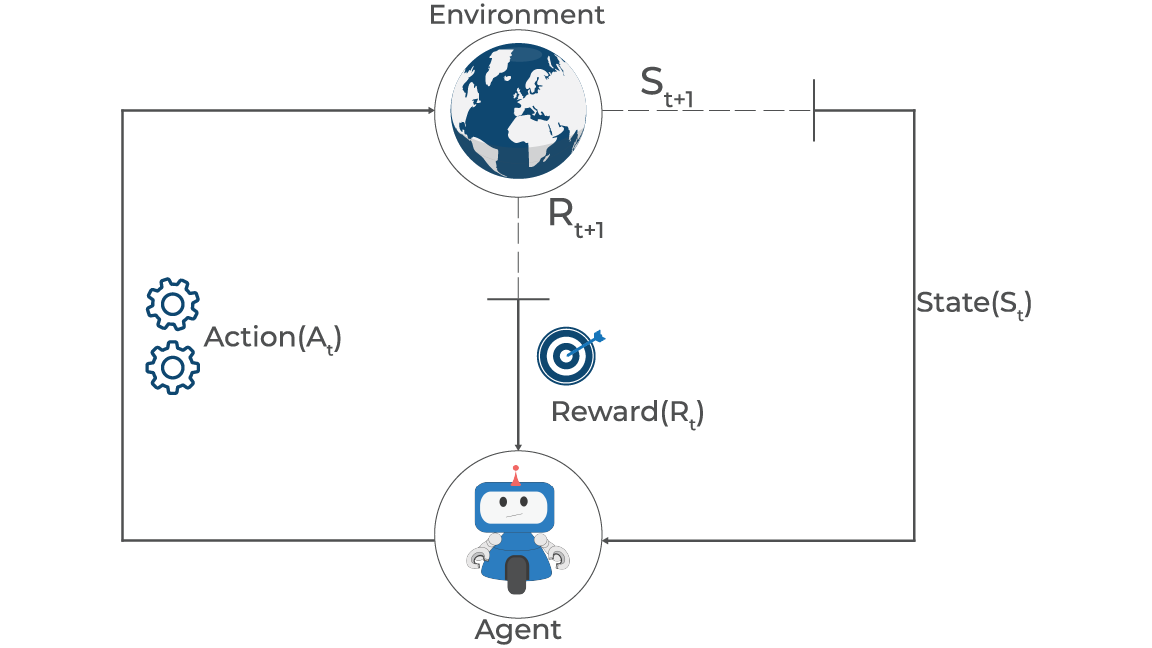</p>

Fig: Reinforcement Learning
</center>

In [8]:
# Multi-armed bandit: three slot machines with hidden win probabilities.
true_win_rates = [0.25, 0.55, 0.75]   # machine index 2 is best; the agent does not know this
n_machines = len(true_win_rates)
n_pulls    = 2000
epsilon    = 0.1                       # 10% of the time explore a random machine, otherwise exploit the best

rng = np.random.default_rng(RANDOM_STATE)
estimated_value = np.zeros(n_machines) # the agent's running estimate of each machine's payout
times_pulled    = np.zeros(n_machines)
reward_history  = []

for t in range(n_pulls):
    # epsilon-greedy policy: mostly exploit, occasionally explore
    if rng.random() < epsilon:
        machine = rng.integers(n_machines)          # explore
    else:
        machine = int(np.argmax(estimated_value))   # exploit best known

    reward = 1 if rng.random() < true_win_rates[machine] else 0   # environment responds

    # Update the running average estimate for the chosen machine
    times_pulled[machine] += 1
    estimated_value[machine] += (reward - estimated_value[machine]) / times_pulled[machine]
    reward_history.append(reward)

print("True win rates      :", true_win_rates)
print("Agent's final guess :", np.round(estimated_value, 2))
print(f"Machine pulled most : #{int(np.argmax(times_pulled))} "
      f"({int(times_pulled.max())} of {n_pulls} pulls); the agent learned which is best")

True win rates      : [0.25, 0.55, 0.75]
Agent's final guess : [0.26 0.63 0.76]
Machine pulled most : #2 (1832 of 2000 pulls); the agent learned which is best


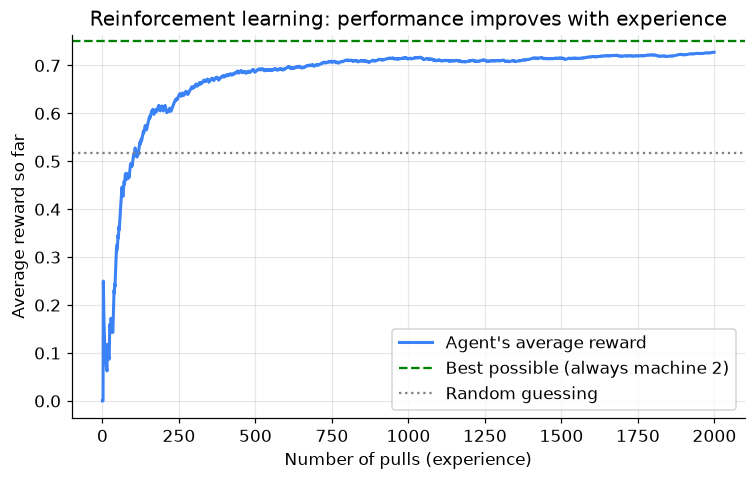

In [9]:
# Plot the running average reward: does the agent improve over time?
running_avg = np.cumsum(reward_history) / (np.arange(n_pulls) + 1)

plt.figure()
plt.plot(running_avg, color="#3b82f6", lw=2, label="Agent's average reward")
plt.axhline(max(true_win_rates), ls="--", color="green", label="Best possible (always machine 2)")
plt.axhline(np.mean(true_win_rates), ls=":", color="gray", label="Random guessing")
plt.xlabel("Number of pulls (experience)")
plt.ylabel("Average reward so far")
plt.title("Reinforcement learning: performance improves with experience")
plt.legend()
plt.tight_layout()
plt.show()

Look at that curve climb. It starts down near random guessing and creeps up toward the best it could possibly
do — and it got there without a single labelled example, just by trying things and paying attention to what
paid off. That's the whole idea in one line.

This is the family behind the flashiest results in the field: the systems that beat the world's best at Go and
chess, robots learning to walk, recommendation feeds that adapt to every tap, even Google using it to cool
their data centres. We give it a full module of its own later, Module 12.

Before you move on, go play with that `epsilon` knob, because it teaches you the explore-exploit lesson better
than I can. Set it to `0.0` — now the agent never explores, it just latches onto whichever machine got lucky
first, and it may spend all 2000 pulls on a mediocre one, blissfully unaware there's a better option. Now set
it to `1.0` — it explores constantly, learns the true rates beautifully, and then throws that knowledge away
by never settling on the winner. Neither extreme works. The magic is somewhere in between, and finding that
"somewhere" is a big part of what makes reinforcement learning hard.

---
## 6. A few finer distinctions worth knowing

Supervised-versus-unsupervised-versus-reinforcement is the big split, but it's not the only way we slice up
models, and you'll hear these next three pairs constantly once you start reading about ML. I'll keep each one
short, but each has a "so what" that actually matters when you're choosing a model, so don't skip the punch
lines.

### 6.1 Model-based vs. instance-based

This one is really a question of *when the work happens*. A model-based method does its thinking up front:
during training it boils the whole dataset down into a compact rule — a boundary, an equation, a set of
weights — and once it has that rule it could honestly throw the data away. Logistic regression is like this.
An instance-based method (people also call these "lazy," which is unfair but memorable) does almost nothing at
training time. It just memorises the examples and waits. The real work happens later, when a new point shows
up and it goes rummaging through its memory for the most similar past examples. K-nearest neighbours is the
classic: to classify a new point, it finds the nearest stored points and lets them vote.

Two doctors make the difference vivid. One studied thousands of cases years ago and now carries general rules
in her head; she treats you from those rules and barely needs to look anything up. The other keeps every file
and, for each new patient, pulls the most similar past patients and copies whatever worked for them. Same
experience, completely different way of using it.

Let me train both on identical data and let you see how differently they carve up the space.

<center>

<p>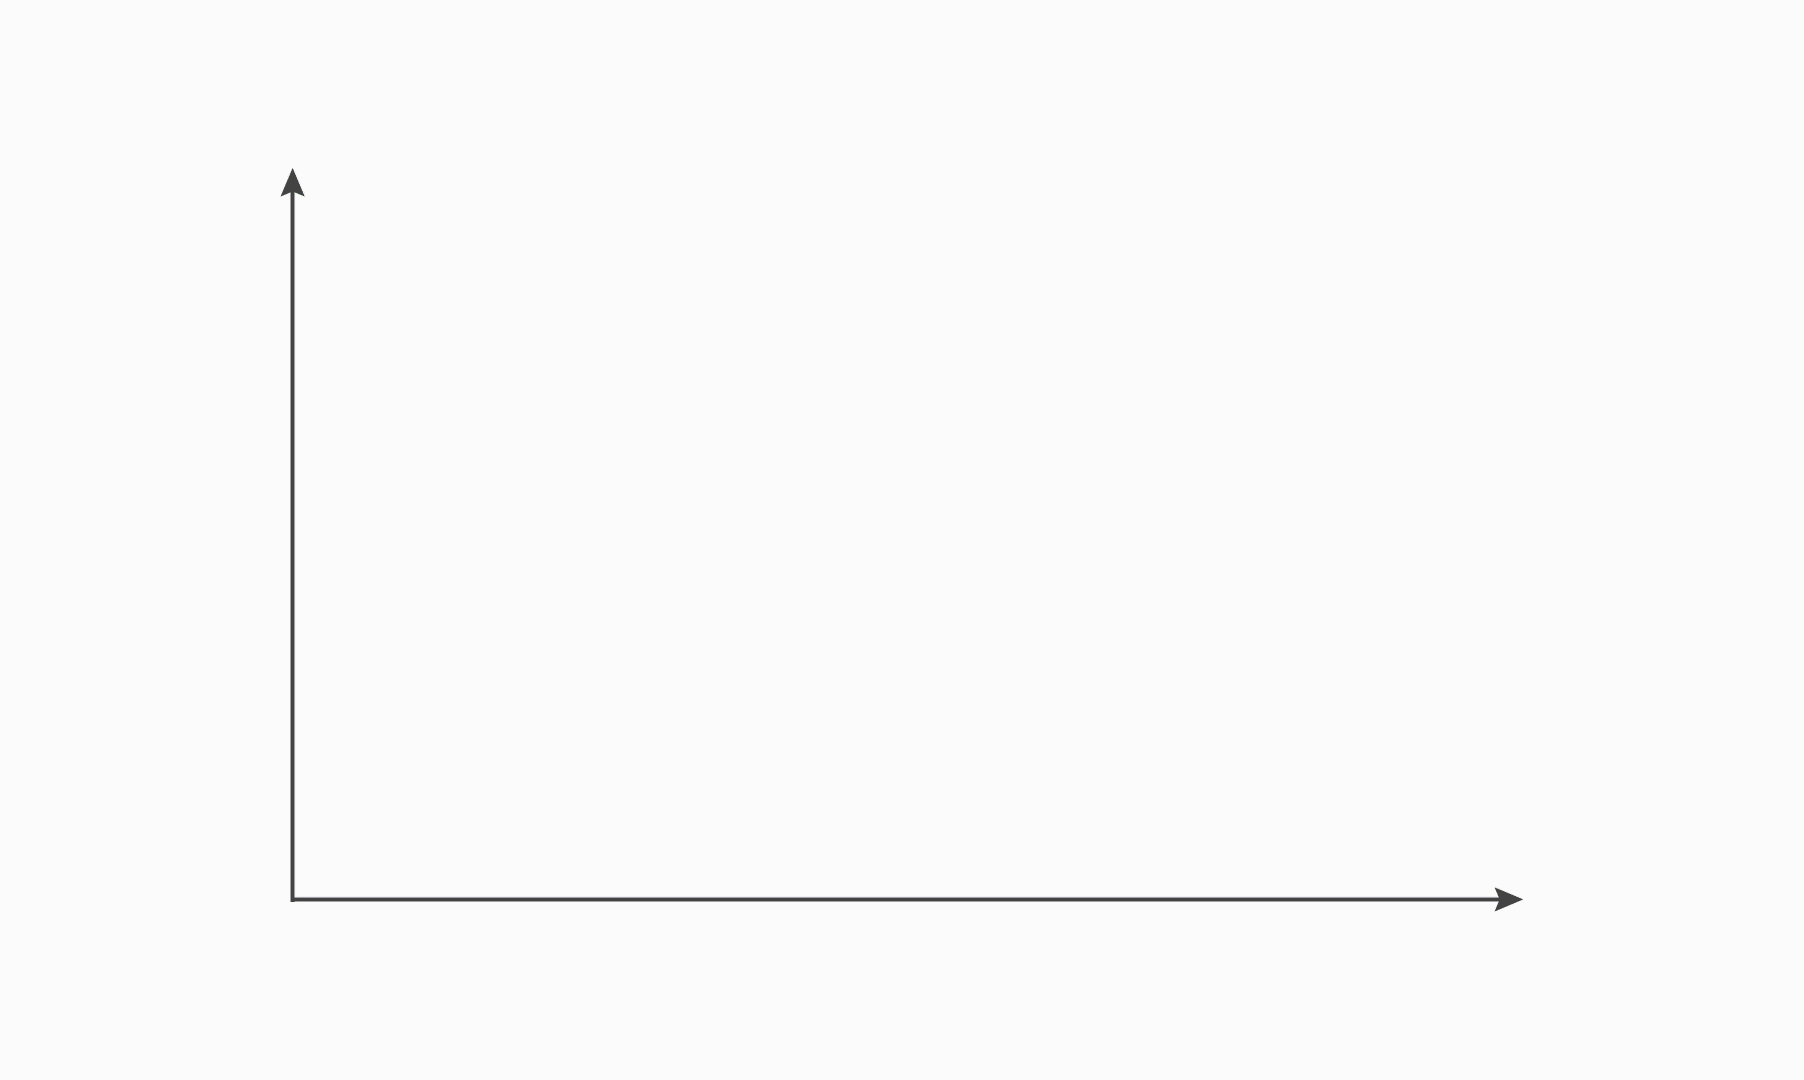</p>
<p>Model-based learning</p>
</center>


<p>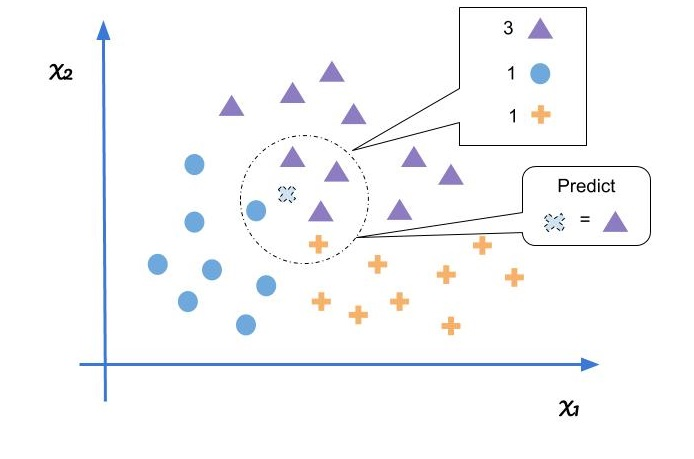</p>

<p>Instance-based learning </p>
</center>


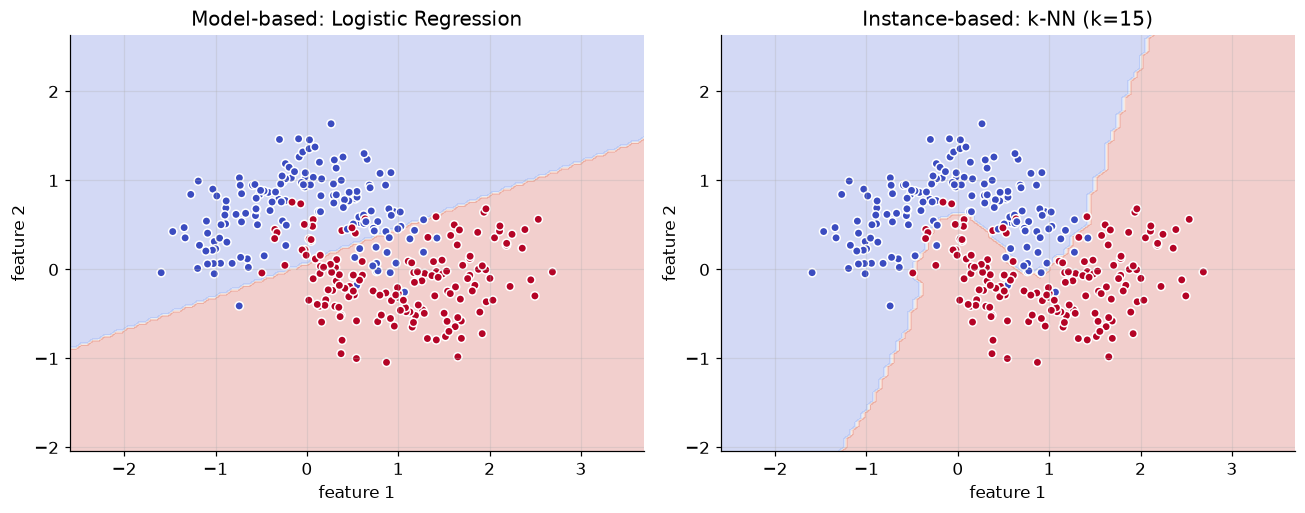

In [10]:
from sklearn.inspection import DecisionBoundaryDisplay

# A curved "two moons" dataset makes the difference in style visible.
X, y = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)

models = [
    ("Model-based: Logistic Regression", LogisticRegression()),
    ("Instance-based: k-NN (k=15)",      KNeighborsClassifier(n_neighbors=15)),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (title, model) in zip(axes, models):
    model.fit(X, y)
    DecisionBoundaryDisplay.from_estimator(model, X, ax=ax, alpha=0.25, cmap="coolwarm",
                                           response_method="predict")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=30)
    ax.set_title(title)
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

Look at the two boundaries side by side and the personalities jump out. Logistic regression drew one clean,
confident line — that's the compact rule it learned. KNN's boundary is all wiggles, hugging the shape of the
data, because it's deciding every little region by asking the local neighbours rather than committing to one
global formula.

So here's a practical question, and it's the kind of thing that actually decides which model you ship. Which
of these two has to lug the entire training set around forever just to make a prediction? And if you had to
run one of them on a phone, thousands of times a second, which would you want? (KNN keeps all the data and
does its work at prediction time; the model-based one just plugs numbers into a formula, so it's far leaner
and faster once trained. Neither is "better" — they're trade-offs.)

### 6.2 Parametric vs. non-parametric

The word "parameters" just means the knobs a model has to tune. The question here is whether that number is
fixed in advance or grows as you feed in more data.

A parametric model decides its number of knobs up front and never changes it. Simple linear regression is the
poster child: it has exactly two knobs, a slope and an intercept, whether you train it on a hundred points or
a hundred million. That's a strong assumption baked in — "the world is a straight line" — and when that
assumption is right, the model is fast and lovely. When it's wrong, no amount of data will save it.

A non-parametric model, by contrast, grows more knobs as the data grows. A decision tree sprouts more branches
the more examples you give it. It assumes much less about the shape of the answer, so it can bend to fit
complicated patterns — but that flexibility is a double-edged sword, as we're about to see.

Watch both try to fit the same wavy data.

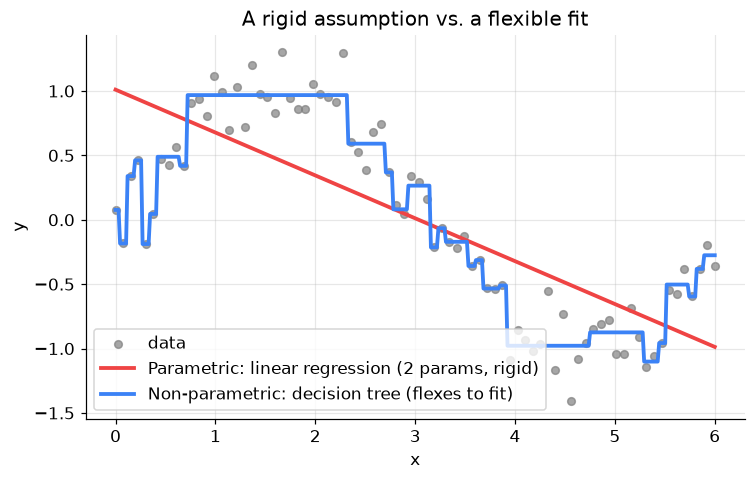

Linear regression parameters : 2 (fixed: slope + intercept)
Decision tree nodes          : 55 (grew from the data)


In [11]:
# Noisy wavy data that is clearly not a straight line.
rng = np.random.default_rng(RANDOM_STATE)
X = np.linspace(0, 6, 80).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(0, 0.25, size=X.shape[0])

lin  = LinearRegression().fit(X, y)                       # parametric: always 2 parameters
tree = DecisionTreeRegressor(max_depth=5).fit(X, y)       # non-parametric: grows with data

X_grid = np.linspace(0, 6, 400).reshape(-1, 1)

plt.figure()
plt.scatter(X, y, s=25, color="gray", alpha=0.7, label="data")
plt.plot(X_grid, lin.predict(X_grid),  color="#ef4444", lw=2.5,
         label="Parametric: linear regression (2 params, rigid)")
plt.plot(X_grid, tree.predict(X_grid), color="#3b82f6", lw=2.5,
         label="Non-parametric: decision tree (flexes to fit)")
plt.title("A rigid assumption vs. a flexible fit")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Linear regression parameters : {lin.coef_.size + 1} (fixed: slope + intercept)")
print(f"Decision tree nodes          : {tree.tree_.node_count} (grew from the data)")

The straight red line simply can't follow a wave — you can see it giving up, cutting straight through the
middle, because "I must be a line" is all it knows how to be. The tree bends and flexes to trace the curve,
because it grew itself extra complexity to match the data.

Now, before you conclude "flexible is just better," here's the catch that we'll spend real time on later. A
model that flexible can start tracing the *noise* — the random jitter in the data — instead of the underlying
signal, essentially memorising the training set instead of learning from it. That failure has a name,
*overfitting*, and it's one of the great villains of this course. Flexibility is power, but power you have to
control. Hold that thought for Modules 4 and 5.

### 6.3 Probabilistic vs. non-probabilistic

Last pair, and it's about *honesty*. Some models don't just blurt out an answer — they tell you how sure they
are. A probabilistic model, like logistic regression or naive Bayes, outputs a probability for each class.
Usually we take the highest one as the prediction, but the number itself is precious: "90% spam" and "51%
spam" are worlds apart, even though both round to "spam." A non-probabilistic model — an SVM, a plain decision
tree, KNN — hands you the class and keeps its doubts to itself.

Why should you care? Because in a lot of real situations, knowing the model is *unsure* is as valuable as the
prediction. "This scan is 55% likely to show a tumour" should trigger a very different response from "99%
likely." Let me make a model show us its confidence.

In [12]:
# Train a probabilistic classifier and ask not just which class, but how confident.
X, y = make_blobs(n_samples=200, centers=2, cluster_std=2.5, random_state=RANDOM_STATE)
clf = LogisticRegression().fit(X, y)

# Three test points: deep in class 0, deep in class 1, and on the boundary.
test_points = np.array([[-8, -8], [8, 8], [0, 0]])
probabilities = clf.predict_proba(test_points)   # the probabilistic output

print("Point            P(class 0)   P(class 1)   Verdict")
print("-" * 55)
for pt, prob in zip(test_points, probabilities):
    verdict = "confident" if max(prob) > 0.8 else "unsure (near boundary)"
    print(f"{str(pt):<16} {prob[0]:>7.1%}     {prob[1]:>7.1%}     {verdict}")

Point            P(class 0)   P(class 1)   Verdict
-------------------------------------------------------
[-8 -8]             5.7%       94.3%     confident
[8 8]               0.0%      100.0%     confident
[0 0]               0.3%       99.7%     confident


Look at the point sitting at `[0, 0]`, right on the fence between the two classes. The model reports something
close to 50/50, which is it being refreshingly honest: "I really don't know which side this belongs to." A
non-probabilistic model would have picked a side and said nothing about the coin-flip underneath. When the
stakes are high — a diagnosis, a loan, a self-driving car deciding whether that's a pedestrian — a model that
can say "I'm not sure" is worth a great deal.

---
## 7. What machine learning can and can't do

I'd be doing you a disservice if I sent you off thinking ML is magic. It's powerful, genuinely, but the
engineers I respect most are the ones who know exactly where it breaks. So let me give you both sides
honestly.

On the strengths: the predictive power is real and a little startling. A century ago, claiming you could
forecast the weather, someone's disease risk, or next month's demand would have got you called a fortune
teller. Now it's routine. ML also finds patterns at a scale no human can — sift through ten million records
and it'll surface structure you'd never spot by hand, sometimes structure no human would ever have thought to
look for. It automates the tedious cognitive grind — fraud checks, triage, data entry — so people can spend
their attention on the things that actually need judgement. And it keeps improving: feed it more good data and
it adapts, without anyone rewriting the rules by hand.

Now the part people gloss over. Every one of those strengths has a shadow.

The biggest is that ML lives or dies by its data. Remember the "add a bad point" experiment back in Section 3,
where one nonsense value dragged the whole line off course? Scale that up. Feed a model biased or
unrepresentative data and you get a biased, unrepresentative model — confidently, and at scale. The slogan to
tattoo on your brain is *garbage in, garbage out.* A model can only ever be as good, and as fair, as what it
learned from.

There are others. Training the big vision and language models eats staggering amounts of compute time and
money. The most accurate models are often the least explainable — they'll give you an answer but not a reason,
which is a serious problem when the law or a patient demands to know *why*. And fundamentally, a model doesn't
*understand* anything; it's optimising a number. Hand it something unlike its training data and it will fail,
and worse, it'll fail with total confidence.

So let me leave you with a genuinely hard question, the kind with no clean answer. A bank is legally required
to explain why it turned down your loan. A hospital wants to flag its highest-risk patients. A game studio
wants a boss that learns your playstyle. For each of those, would you reach for a simple rule, an interpretable
model, or a powerful black box? There's a real tension between accuracy and explainability, and choosing where
to sit on it is an engineering *and* an ethical decision — not something a formula decides for you.

---
## 8. Putting it all together

We've covered a lot of ground, so let me tie it into a bow with one small project that touches everything
we've talked about. We'll use the Iris dataset — 150 flowers, four measurements each, and the job is to
predict which of three species each flower is. It's the "hello world" of machine learning, and there's no
shame in that.

Here's what I want you to do as you read the code below: don't just skim it, hunt for the four components from
Section 4. Where's the *data*? Where do we pick the *model*? Which single line is where the *learning*
happens? And where do we finally *apply* it? I've labelled them in the comments, but try to spot them before
you read the labels.

In [13]:
# 1. DATA: 150 iris flowers, four measurements each, three species.
iris = load_iris()
X, y = iris.data, iris.target
print(f"Data: {X.shape[0]} flowers, {X.shape[1]} features each, {len(np.unique(y))} species")

# Honest evaluation: hold out 30% the model never sees during training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

# 2. MODEL and 3. LEARNING: choose a model, then fit() runs the objective and optimization.
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)          # learning happens here

# 4. APPLICATION: predict on unseen flowers and measure performance.
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy on unseen flowers: {accuracy:.1%}")

# A probabilistic view (Section 6.3): how confident is the model on the first test flower?
first_probs = model.predict_proba(X_test[:1])[0]
print("\nConfidence on the first unseen flower:")
for name, p in zip(iris.target_names, first_probs):
    print(f"   {name:<12} {p:.1%}")
print(f"Predicted: {iris.target_names[predictions[0]]} | Actual: {iris.target_names[y_test[0]]}")

Data: 150 flowers, 4 features each, 3 species
Accuracy on unseen flowers: 93.3%

Confidence on the first unseen flower:
   setosa       0.0%
   versicolor   3.2%
   virginica    96.8%
Predicted: virginica | Actual: virginica


And that's a complete machine learning project. Take a second to appreciate how much happened in those few
lines: we chose our data, we held some of it back so we could grade the model honestly on flowers it had never
seen, we picked a model, we let it learn, we tested it, we scored it, and we even asked how confident it was.
Everything we discussed today, all in one small loop. Every single remaining module in this course is, in some
sense, just a deep dive into one piece of what you see here.

One last thing before we wrap — make it yours. Swap `LogisticRegression` for
`KNeighborsClassifier(n_neighbors=3)`, or for a `DecisionTreeClassifier()` (you'll need to import it), and
re-run. Which one gets the best score on Iris? The moment you compare two models on held-out data and pick a
winner, you've done your first real model comparison — a skill we build into a proper discipline in Module 13.

---
## 9. Your turn

Reading about this stuff and *doing* it are completely different experiences, and only one of them sticks.
So here are some exercises. They start gentle and get more open-ended toward the end; work through them in
order and add your own cells underneath each. Don't worry about getting them perfect — the point is to poke at
the ideas until they feel like yours.

**Exercise 1 — Classify the scenario (no code).**

For each task, name the type (supervised, unsupervised, or reinforcement) and, if supervised, whether it is
classification or regression:

1. Predicting tomorrow's temperature from today's weather.
2. Grouping a store's customers into types for marketing, with no predefined groups.
3. Teaching a drone to fly through a hoop, rewarding successful passes.
4. Detecting whether a transaction is fraudulent from 50,000 labelled past transactions.
5. Recommending a movie by finding users with similar taste.

**Exercise 2 — Change the rule.**

Return to the Celsius-to-Fahrenheit demonstration (Section 3). Replace the data with values that follow the
rule $F = 2C + 10$ (invent about six points). Re-fit the model. Does it recover a slope of 2 and an intercept
of 10?

**Exercise 3 — Regression rather than classification.**

Generate `X = np.linspace(0, 10, 50)` and `y = 3*X + 7 + noise`, fit a `LinearRegression`, and plot the data
with the fitted line. Print the learned slope and intercept and compare them to 3 and 7.

**Exercise 4 — How many clusters?**

In the KMeans demonstration (Section 5.2), change `n_clusters` to 2, then 4, then 5, re-plotting each time.
Which looks the most natural for three-blob data? Write one sentence on why choosing the number of clusters is
difficult.

**Exercise 5 — Explore vs. exploit.**

In the bandit simulation (Section 5.3), try `epsilon` values of 0.0, 0.01, 0.1, and 0.5. Plot the final
average reward for each. Which explores too little, which too much, and where is the balance?

**Exercise 6 — Model comparison (challenge).**

On the Iris example, train `LogisticRegression`, `KNeighborsClassifier`, and `DecisionTreeClassifier`. Print
each one's test accuracy in a small table. For each, note whether it is model-based or instance-based, and
parametric or non-parametric (Section 6).

**Reflection questions.**

- The word "learning" describes both a child learning to walk and a model minimising mean squared error. In
  what way is the machine's learning different from a person's?
- Machine learning models can find patterns beyond human comprehension. Why is that both an advantage and a
  risk?
- Give one example where you would deliberately choose a less accurate but more interpretable model.

---
## 10. Where we go from here

You're standing at Module 1, and I know the road ahead can look like a long list of intimidating algorithm
names. So let me reframe it for you: almost everything to come is just a deeper look at one piece of that
little pipeline you built in Section 8. Keep this table somewhere — when a later module starts to feel like it
came from nowhere, come back here and find where it slots into the bigger picture.

| Module | Topic | Part of the pipeline |
|:---:|---|---|
| 1 (this module) | Introduction to ML | the whole picture |
| 2 | Linear Regression | model and optimization (OLS, gradient descent, regularization) |
| 3 | Logistic Regression | classification, sigmoid, cross-entropy, softmax |
| 4 | Decision Trees | non-parametric models, overfitting, pruning |
| 5 | Ensemble Methods | combining models (bagging, boosting, Random Forest, XGBoost) |
| 6 | k-Nearest Neighbours | instance-based learning |
| 7 | Support Vector Machines | maximum-margin classifiers, the kernel trick |
| 8 | Probabilistic Models | MLE, MAP, Bayesian estimation |
| 9 | Clustering | unsupervised learning, choosing the number of clusters |
| 10 | Dimensionality Reduction | PCA, SVD |
| 11 | Time Series Analysis | ARIMA, forecasting |
| 12 | Reinforcement Learning | agents, policies, Markov decision processes |
| 13 | Deployment and Ops | serving a trained model on the web (Flask) |

Every idea we touched today — data, model, objective, optimization, the three types of supervision, the
parametric and probabilistic distinctions — is going to come back, with more depth each time. Think of today
as the map. The rest of the course is us actually walking the territory.

---
## 11. If you remember nothing else

We covered a lot, so let me boil the day down to the handful of things I'd genuinely want you to carry out of
this room:

1. AI, ML, and DL are nested circles, not synonyms. AI is the ambition, ML is learning the rules from data,
   and DL is ML built from many layers of neurons.
2. Here's the big one: traditional programming turns *rules + data* into answers; machine learning turns
   *data + answers* into rules. The rule is learned, not written — we literally watched a machine rediscover
   $F = 1.8C + 32$ from eight dots.
3. Mitchell's test for whether something is really learning: does its performance $P$ on a task $T$ actually
   improve with experience $E$? If not, it isn't learning.
4. Every ML system, no exceptions, is four parts: data, model, learning (an objective plus optimization), and
   application. Learn to spot them.
5. Three types of learning, three personalities: supervised learns from answers, unsupervised finds structure
   without them, reinforcement learns from reward.
6. Three finer distinctions worth knowing: model-based vs. instance-based, parametric vs. non-parametric, and
   probabilistic vs. non-probabilistic.
7. And finally: it's powerful, not magic. Garbage in, garbage out. Watch your data, your compute budget,
   whether you can explain the thing, and the fact that it doesn't truly understand anything.

---
## 12. Further reading and glossary

### Further reading

If today sparked something, here's where I'd point you next. Don't feel you have to read all of it — pick
whatever matches your mood.

- Pedro Domingos, [A Few Useful Things to Know About Machine Learning](https://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf) — if you read one thing, read this. Short, wise, and it'll make more sense every time you come back to it.
- Google, [Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course) — free and hands-on, good if you like learning by clicking.
- 3Blue1Brown, [Neural Networks (YouTube)](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) — save this for when we reach deep learning; the visuals are gorgeous and will do half my job for me.
- scikit-learn, [Choosing the right estimator](https://scikit-learn.org/stable/tutorial/machine_learning_map/) — a practical flowchart for "which algorithm do I even use," handy once you're building things.

### Glossary

| Term | Meaning |
|---|---|
| Feature | An input variable (a column of the data). |
| Label / target | The answer to be predicted (supervised learning). |
| Model | The adjustable form of the rule the machine learns. |
| Training / fitting | The process of adjusting the model to the data. |
| Objective / loss function | A score of how wrong the model is, which we minimise. |
| Optimization | The algorithm that reduces the loss, e.g. gradient descent. |
| Hypothesis space | The set of all rules a chosen model can represent. |
| Overfitting | Memorising noise in the training data, leading to poor performance on new data. |
| Generalization | Performing well on data the model has not seen. |
| Decision boundary | The surface a classifier uses to separate classes. |
| Policy (RL) | An agent's strategy: which action to take in each state. |

---

That's Module 1. You came in maybe picturing a movie robot, and you're leaving having run supervised,
unsupervised, and reinforcement learning with your own hands and built a working ML pipeline from scratch.
That's a real day's work — nice job. Next time, in Module 2, we crack open the linear regression model we
leaned on today and see exactly how it learns, gear by gear. See you there.

*DCS 404 — Data Science and Machine Learning*

*&copy; 2026 Aayush Raj Regmi, All Rights Reserved.*